In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
from google.colab import files
uploaded = files.upload()

# List the uploaded files
print(uploaded.keys())

# Read the CSV file
df = pd.read_csv('2_spotify_10_songs.csv')


dict_keys([])


In [ ]:
df.columns

Index(['song_name                                                               ',
       'artist               ', 'danceability ', 'energy  ', 'key ',
       'loudness ', 'mode ', 'speechiness ', 'acousticness ',
       'instrumentalness ', 'liveness ', 'valence ', 'tempo   ',
       'duration_ms ', 'time_signature ', 'id                     ', 'html'],
      dtype='object')

In [ ]:
df.set_index('song_name                                                               ', inplace=True)

In [ ]:
df

,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html
song_name,,,,,,,,,,,,,,,,
My Band,D12,0.851,0.84900,1,-3.383,0,0.0828,0.49700,0.000002,0.1160,0.8440,120.014,298773,4,4XHQyvbrBsQaaBUW1VvmsL,https://open.spotify.com/track/4XHQyvbrBsQaaBU...
The Real Slim Shady,Eminem,0.949,0.66100,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.7600,104.504,284200,4,3yfqSUWxFvZELEM4PmlwIR,https://open.spotify.com/track/3yfqSUWxFvZELEM...
Águas De Março,Antônio Carlos Jobim,0.642,0.33900,3,-15.503,1,0.1400,0.85400,0.000000,0.1050,0.4910,143.418,212400,4,1y7OxO5i6sfrHXAmUM77YG,https://open.spotify.com/track/1y7OxO5i6sfrHXA...
The Girl From Ipanema,Stan Getz,0.641,0.14000,8,-16.790,1,0.0390,0.86700,0.001660,0.1050,0.3880,129.318,317987,4,3898C4AbdbptwYet6547e5,https://open.spotify.com/track/3898C4AbdbptwYe...
"Paint It, Black",The Rolling Stones,0.464,0.79500,1,-9.267,1,0.0926,0.04930,0.002440,0.3990,0.6120,158.691,202267,4,63T7DJ1AFDD6Bn8VzG6JE8,https://open.spotify.com/track/63T7DJ1AFDD6Bn8...
Sultans Of Swing,Dire Straits,0.733,0.79400,5,-10.023,1,0.0307,0.06140,0.036700,0.3300,0.9310,148.174,348624,4,6cr6UDpkjEaMQ80OjWqEBQ,https://open.spotify.com/track/6cr6UDpkjEaMQ80...
Space Raiders - Charlotte de Witte Remix,Eats Everything,0.749,0.73100,4,-10.865,1,0.1080,0.00314,0.867000,0.1110,0.0598,131.997,438720,4,4F8OK7mNa51mKqgHqWQiYm,https://open.spotify.com/track/4F8OK7mNa51mKqg...
In Silence,Amelie Lens,0.736,0.84500,1,-12.017,1,0.0377,0.00548,0.901000,0.1110,0.1980,128.009,393740,4,2vfSCFvMbpf4hwxt22Wx7b,https://open.spotify.com/track/2vfSCFvMbpf4hwx...
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",Johannes Brahms,0.184,0.00833,3,-33.503,1,0.0519,0.98900,0.596000,0.1040,0.2110,61.541,109800,3,59cPOVxrn3Yjwydl1pullI,https://open.spotify.com/track/59cPOVxrn3Yjwyd...


In [ ]:
df.drop(columns=['id                     ', 'html', 'artist               '], inplace=True)

In [ ]:
df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
song_name,,,,,,,,,,,,,
My Band,0.851,0.84900,1,-3.383,0,0.0828,0.49700,0.000002,0.1160,0.8440,120.014,298773,4
The Real Slim Shady,0.949,0.66100,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.7600,104.504,284200,4
Águas De Março,0.642,0.33900,3,-15.503,1,0.1400,0.85400,0.000000,0.1050,0.4910,143.418,212400,4
The Girl From Ipanema,0.641,0.14000,8,-16.790,1,0.0390,0.86700,0.001660,0.1050,0.3880,129.318,317987,4
"Paint It, Black",0.464,0.79500,1,-9.267,1,0.0926,0.04930,0.002440,0.3990,0.6120,158.691,202267,4
Sultans Of Swing,0.733,0.79400,5,-10.023,1,0.0307,0.06140,0.036700,0.3300,0.9310,148.174,348624,4
Space Raiders - Charlotte de Witte Remix,0.749,0.73100,4,-10.865,1,0.1080,0.00314,0.867000,0.1110,0.0598,131.997,438720,4
In Silence,0.736,0.84500,1,-12.017,1,0.0377,0.00548,0.901000,0.1110,0.1980,128.009,393740,4
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",0.184,0.00833,3,-33.503,1,0.0519,0.98900,0.596000,0.1040,0.2110,61.541,109800,3


### Two dimensional clustering

In [ ]:
average_scores = df.mean()

In [ ]:
average_scores

danceability              0.633600
energy                    0.520743
key                       3.400000
loudness                -14.029300
mode                      0.800000
speechiness               0.067630
acousticness              0.434652
instrumentalness          0.331780
liveness                  0.153840
valence                   0.456580
tempo                   118.716000
duration_ms          287493.800000
time_signature            3.900000
dtype: float64

In [ ]:
two_dim_df = df.loc[:, ['energy  ', 'danceability ']].copy()

In [ ]:
two_dim_df

,energy,danceability
song_name,,
My Band,0.84900,0.851
The Real Slim Shady,0.66100,0.949
Águas De Março,0.33900,0.642
The Girl From Ipanema,0.14000,0.641
"Paint It, Black",0.79500,0.464
Sultans Of Swing,0.79400,0.733
Space Raiders - Charlotte de Witte Remix,0.73100,0.749
In Silence,0.84500,0.736
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",0.00833,0.184


In [ ]:
# Now we will .fit() the k-means model to our data.
music_obj = KMeans(n_clusters=3, random_state=24)

In [ ]:
music_obj.fit(two_dim_df)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=3, random_state=24)

In [ ]:
music_obj.cluster_centers_

array([[0.2395    , 0.6415    ],
       [0.77916667, 0.747     ],
       [0.026715  , 0.2855    ]])

In [ ]:
music_obj.labels_

array([1, 1, 0, 0, 1, 1, 1, 1, 2, 2], dtype=int32)

In [ ]:
table = music_obj.labels_
two_dim_df['table'] = table
two_dim_df.sort_values(by="table")

,energy,danceability,table
song_name,,,
Águas De Março,0.33900,0.642,0
The Girl From Ipanema,0.14000,0.641,0
My Band,0.84900,0.851,1
The Real Slim Shady,0.66100,0.949,1
"Paint It, Black",0.79500,0.464,1
Sultans Of Swing,0.79400,0.733,1
Space Raiders - Charlotte de Witte Remix,0.73100,0.749,1
In Silence,0.84500,0.736,1
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",0.00833,0.184,2


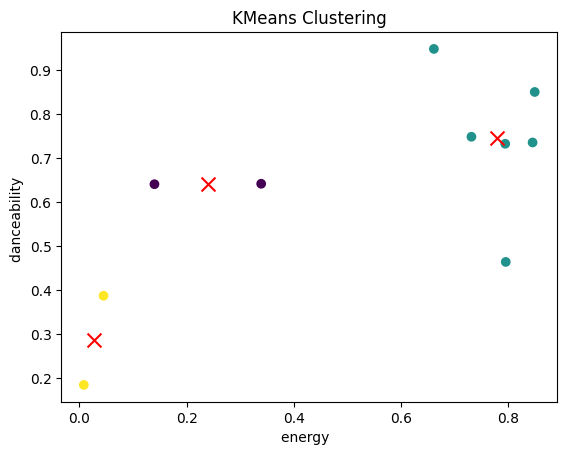

In [ ]:
# @title Clusters and centroids

# Plot the data points
plt.scatter(x = two_dim_df.loc[:, 'energy  '],
            y = two_dim_df.loc[:, 'danceability '],
            c = music_obj.labels_,
            cmap = 'viridis')

# Plot the cluster centers
plt.scatter(x = music_obj.cluster_centers_[:, 0],
            y = music_obj.cluster_centers_[:, 1],
            c = 'red',
            marker = 'x',
            s = 100)

# Add labels and title
plt.title('KMeans Clustering')
plt.xlabel(two_dim_df.columns[0])
plt.ylabel(two_dim_df.columns[1])

# Display the plot
plt.show()

### Clustering in multiple dimension

In [ ]:
full_music_obj = KMeans(n_clusters=3, random_state=10)

In [ ]:
full_music_obj = KMeans(n_clusters=3, random_state=10)
full_music_obj.fit(df)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=3, random_state=10)

In [ ]:
full_music_obj.cluster_centers_

array([[ 7.12200000e-01,  4.97820000e-01,  4.40000000e+00,
        -1.18276000e+01,  6.00000000e-01,  4.92200000e-02,
         4.89120000e-01,  1.90272410e-01,  1.41680000e-01,
         5.98800000e-01,  1.12700800e+02,  3.03602200e+05,
         4.00000000e+00, -1.11022302e-16],
       [ 4.30000000e-01,  3.80776667e-01,  2.33333333e+00,
        -1.94243333e+01,  1.00000000e+00,  9.48333333e-02,
         6.30766667e-01,  1.99480000e-01,  2.02666667e-01,
         4.38000000e-01,  1.21216667e+02,  1.74822333e+05,
         3.66666667e+00,  1.00000000e+00],
       [ 7.42500000e-01,  7.88000000e-01,  2.50000000e+00,
        -1.14410000e+01,  1.00000000e+00,  7.28500000e-02,
         4.31000000e-03,  8.84000000e-01,  1.11000000e-01,
         1.28900000e-01,  1.30003000e+02,  4.16230000e+05,
         4.00000000e+00,  2.00000000e+00]])

In [ ]:
full_music_obj.labels_

array([0, 0, 1, 0, 1, 0, 2, 2, 1, 0], dtype=int32)

In [ ]:
table = full_music_obj.labels_
df['table'] = table
df.sort_values(by='table')

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,table
song_name,,,,,,,,,,,,,,
My Band,0.851,0.84900,1,-3.383,0,0.0828,0.49700,0.000002,0.1160,0.8440,120.014,298773,4,0
The Real Slim Shady,0.949,0.66100,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.7600,104.504,284200,4,0
The Girl From Ipanema,0.641,0.14000,8,-16.790,1,0.0390,0.86700,0.001660,0.1050,0.3880,129.318,317987,4,0
Sultans Of Swing,0.733,0.79400,5,-10.023,1,0.0307,0.06140,0.036700,0.3300,0.9310,148.174,348624,4,0
Nocturne en mi bémol majeur opus 9 n°2: Ballade en Sol Mineur No.1,0.387,0.04510,3,-24.698,1,0.0364,0.99000,0.913000,0.1120,0.0710,61.494,268427,4,0
Águas De Março,0.642,0.33900,3,-15.503,1,0.1400,0.85400,0.000000,0.1050,0.4910,143.418,212400,4,1
"Paint It, Black",0.464,0.79500,1,-9.267,1,0.0926,0.04930,0.002440,0.3990,0.6120,158.691,202267,4,1
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",0.184,0.00833,3,-33.503,1,0.0519,0.98900,0.596000,0.1040,0.2110,61.541,109800,3,1
Space Raiders - Charlotte de Witte Remix,0.749,0.73100,4,-10.865,1,0.1080,0.00314,0.867000,0.1110,0.0598,131.997,438720,4,2


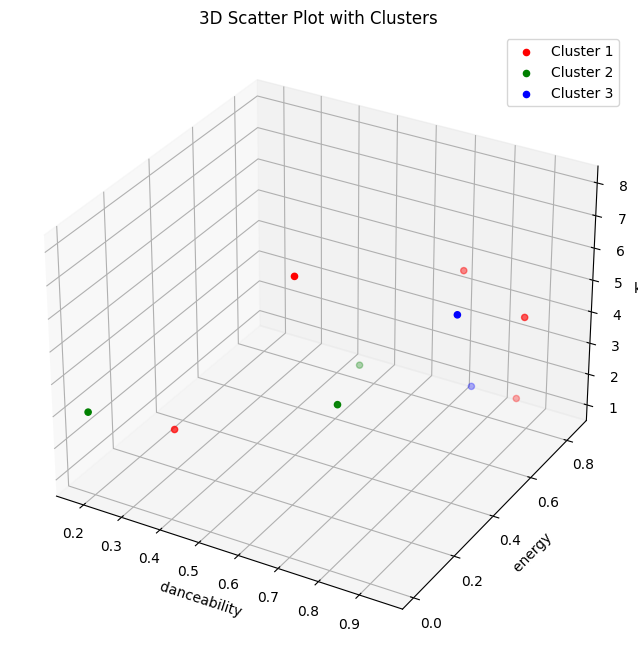

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define colors for clusters
colors = ['red', 'green', 'blue']
for i in range(3):
    cluster = df[df['table'] == i]
    ax.scatter(cluster.iloc[:, 0], cluster.iloc[:, 1], cluster.iloc[:, 2], c=colors[i], label=f'Cluster {i + 1}')

ax.set_xlabel(df.columns[0])
ax.set_ylabel(df.columns[1])
ax.set_zlabel(df.columns[2])
ax.set_title('3D Scatter Plot with Clusters')
ax.legend()

plt.show()


### Scaling the data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer
from sklearn import set_config
set_config(transform_output = "pandas")

In [4]:
from sklearn import set_config
set_config(transform_output = "pandas")

In [7]:
from google.colab import files
uploaded = files.upload()

# List the uploaded files
print(uploaded.keys())

# Read the CSV file
df = pd.read_csv('2_spotify_10_songs.csv')

Saving 2_spotify_10_songs.csv to 2_spotify_10_songs (1).csv
dict_keys(['2_spotify_10_songs (1).csv'])


In [5]:
df.columns

Index(['song_name                                                               ',
       'artist               ', 'danceability ', 'energy  ', 'key ',
       'loudness ', 'mode ', 'speechiness ', 'acousticness ',
       'instrumentalness ', 'liveness ', 'valence ', 'tempo   ',
       'duration_ms ', 'time_signature ', 'id                     ', 'html'],
      dtype='object')

In [6]:
df.drop(columns=['id                     ', 'html', 'artist               '], inplace=True)

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['song_name', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature'],
      dtype='object')

In [9]:
df

,song_name,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,My Band ...,0.851,0.84900,1,-3.383,0,0.0828,0.49700,0.000002,0.1160,0.8440,120.014,298773,4
1,The Real Slim Shady ...,0.949,0.66100,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.7600,104.504,284200,4
2,Águas De Março ...,0.642,0.33900,3,-15.503,1,0.1400,0.85400,0.000000,0.1050,0.4910,143.418,212400,4
3,The Girl From Ipanema ...,0.641,0.14000,8,-16.790,1,0.0390,0.86700,0.001660,0.1050,0.3880,129.318,317987,4
4,"Paint It, Black ...",0.464,0.79500,1,-9.267,1,0.0926,0.04930,0.002440,0.3990,0.6120,158.691,202267,4
5,Sultans Of Swing ...,0.733,0.79400,5,-10.023,1,0.0307,0.06140,0.036700,0.3300,0.9310,148.174,348624,4
6,Space Raiders - Charlotte de Witte Remix ...,0.749,0.73100,4,-10.865,1,0.1080,0.00314,0.867000,0.1110,0.0598,131.997,438720,4
7,In Silence ...,0.736,0.84500,1,-12.017,1,0.0377,0.00548,0.901000,0.1110,0.1980,128.009,393740,4
8,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and ...",0.184,0.00833,3,-33.503,1,0.0519,0.98900,0.596000,0.1040,0.2110,61.541,109800,3
9,Nocturne en mi bémol majeur opus 9 n°2: Ballad...,0.387,0.04510,3,-24.698,1,0.0364,0.99000,0.913000,0.1120,0.0710,61.494,268427,4


In [10]:
df.set_index('song_name', inplace=True)

In [11]:
df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
song_name,,,,,,,,,,,,,
My Band,0.851,0.84900,1,-3.383,0,0.0828,0.49700,0.000002,0.1160,0.8440,120.014,298773,4
The Real Slim Shady,0.949,0.66100,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.7600,104.504,284200,4
Águas De Março,0.642,0.33900,3,-15.503,1,0.1400,0.85400,0.000000,0.1050,0.4910,143.418,212400,4
The Girl From Ipanema,0.641,0.14000,8,-16.790,1,0.0390,0.86700,0.001660,0.1050,0.3880,129.318,317987,4
"Paint It, Black",0.464,0.79500,1,-9.267,1,0.0926,0.04930,0.002440,0.3990,0.6120,158.691,202267,4
Sultans Of Swing,0.733,0.79400,5,-10.023,1,0.0307,0.06140,0.036700,0.3300,0.9310,148.174,348624,4
Space Raiders - Charlotte de Witte Remix,0.749,0.73100,4,-10.865,1,0.1080,0.00314,0.867000,0.1110,0.0598,131.997,438720,4
In Silence,0.736,0.84500,1,-12.017,1,0.0377,0.00548,0.901000,0.1110,0.1980,128.009,393740,4
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",0.184,0.00833,3,-33.503,1,0.0519,0.98900,0.596000,0.1040,0.2110,61.541,109800,3


In [12]:
pairwise_dis_df = pd.DataFrame(pairwise_distances(df),
             index=df.index,
             columns=df.index
            )
pairwise_dis_df

song_name,My Band,The Real Slim Shady,Águas De Março,The Girl From Ipanema,"Paint It, Black",Sultans Of Swing,Space Raiders - Charlotte de Witte Remix,In Silence,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",Nocturne en mi bémol majeur opus 9 n°2: Ballade en Sol Mineur No.1
song_name,,,,,,,,,,
My Band,0.000000,14573.008837,86373.004053,19214.008255,96506.007937,49851.008569,139947.000755,94967.000742,188973.011468,30346.064036
The Real Slim Shady,14573.008837,0.000000,71800.011470,33787.011607,81933.018179,64424.015069,154520.002598,109540.002881,174400.007771,15773.072153
Águas De Março,86373.004053,71800.011470,0.000000,105587.001068,10133.013675,136224.000212,226320.000342,181340.000704,102600.034257,56027.060661
The Girl From Ipanema,19214.008255,33787.011607,105587.001068,0.000000,115720.004190,30637.006720,120733.000250,75753.000499,208187.011767,49560.047303
"Paint It, Black",96506.007937,81933.018179,10133.013675,115720.004190,0.000000,146357.000435,236453.001534,191473.002481,92467.054250,66160.073247
Sultans Of Swing,49851.008569,64424.015069,136224.000212,30637.006720,146357.000435,0.000000,90096.001470,45116.004743,238824.016883,80197.048230
Space Raiders - Charlotte de Witte Remix,139947.000755,154520.002598,226320.000342,120733.000250,236453.001534,90096.001470,0.000000,44980.000292,328920.008331,170293.015164
In Silence,94967.000742,109540.002881,181340.000704,75753.000499,191473.002481,45116.004743,44980.000292,0.000000,283940.008605,125313.018317
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",188973.011468,174400.007771,102600.034257,208187.011767,92467.054250,238824.016883,328920.008331,283940.008605,0.000000,158627.000248


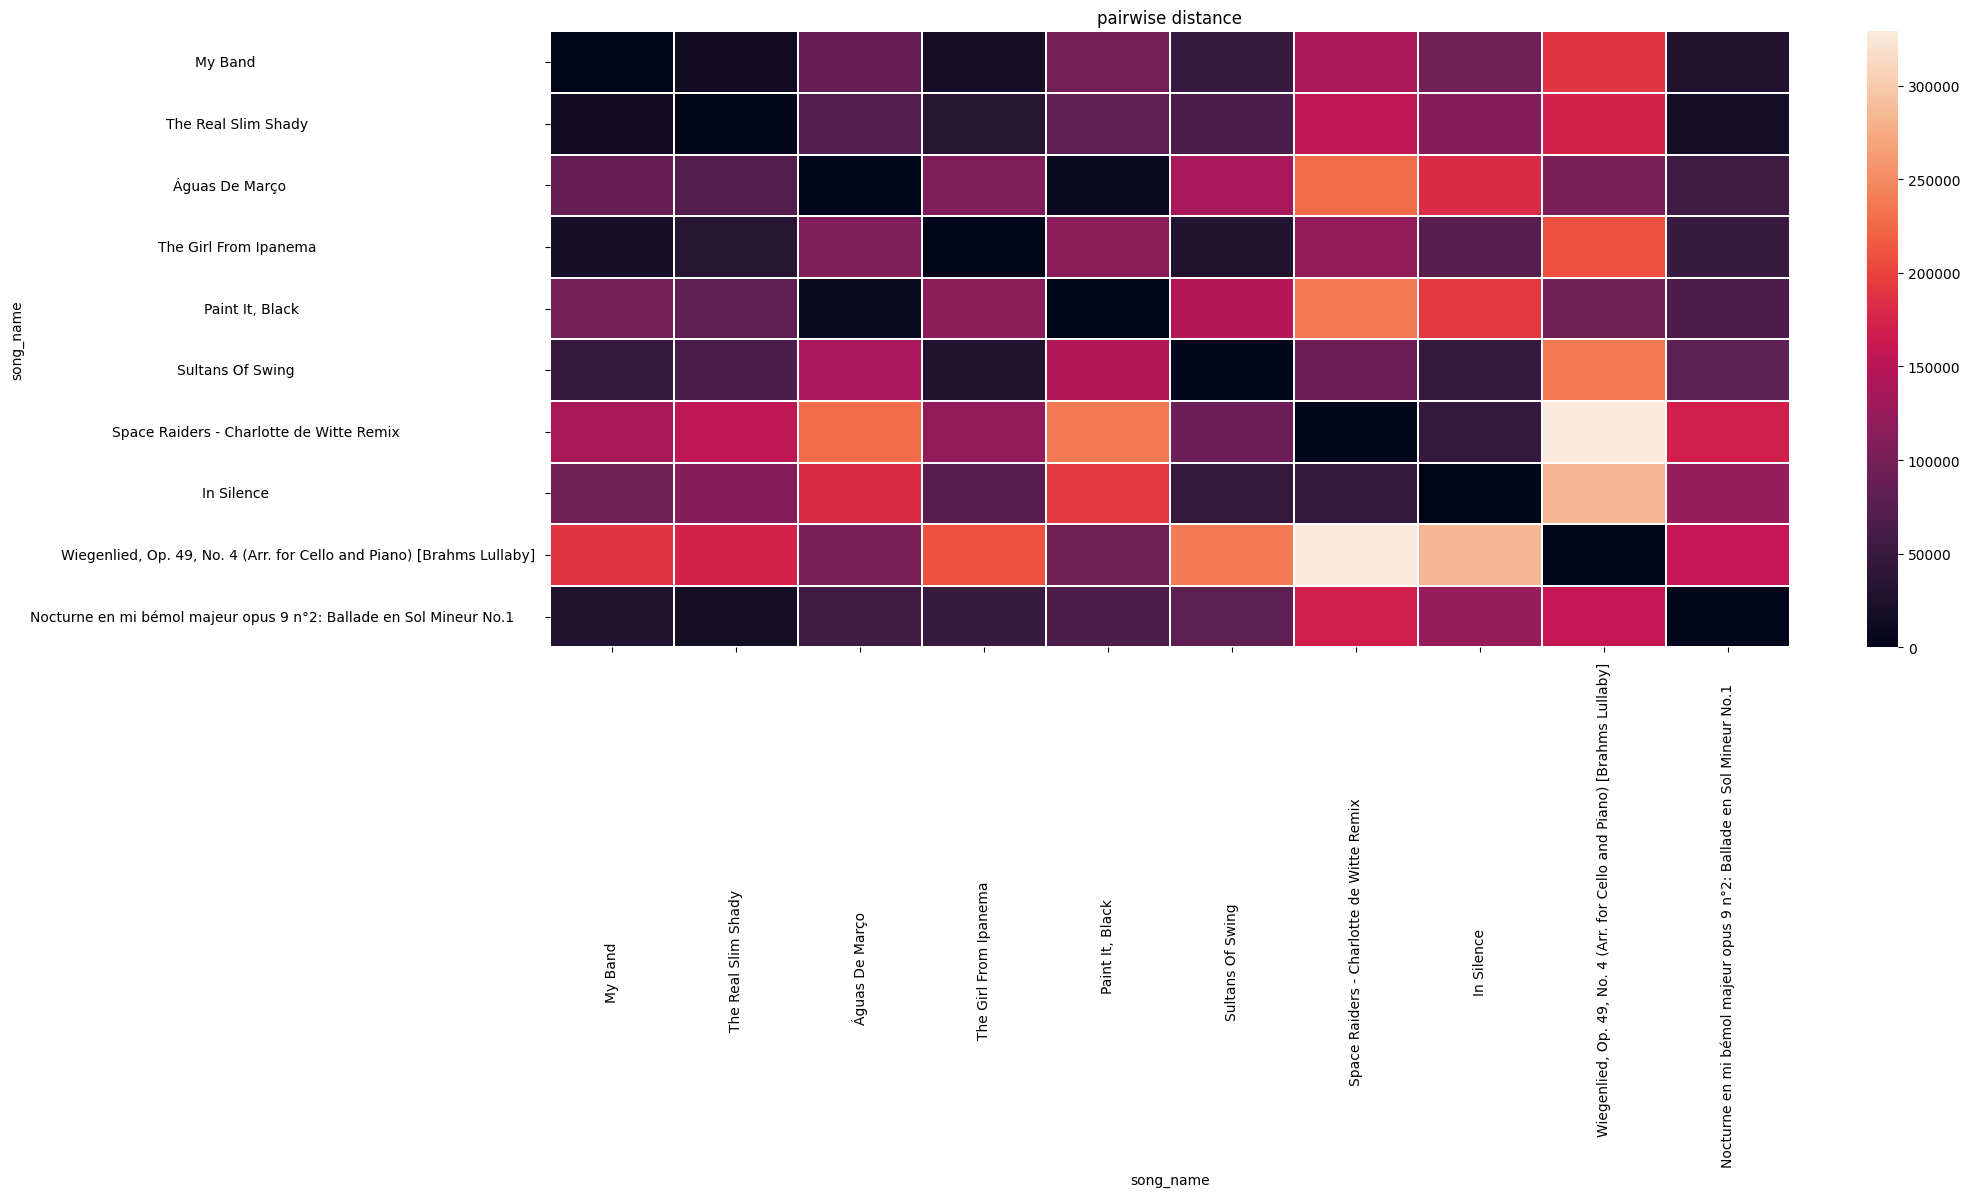

In [13]:
# Stating that we want two plots. we use pairedwise df to plot our heatmap
fig, ax = plt.subplots(1, figsize=(20, 8))

sns.heatmap(pairwise_dis_df, ax=ax, linewidths=.2);

ax.set_title('pairwise distance')
plt.show()

### Here we start scaling our data and at the end we will compare the results on KMeans algorithm
* MinMax scaler

In [14]:
# initialise scaler object
scaler_1 = MinMaxScaler()

In [15]:
scaler_1.fit(df)

MinMaxScaler()

In [16]:
scaler_1.data_max_

array([ 9.49000e-01,  8.49000e-01,  8.00000e+00, -3.38300e+00,
        1.00000e+00,  1.40000e-01,  9.90000e-01,  9.13000e-01,
        3.99000e-01,  9.31000e-01,  1.58691e+02,  4.38720e+05,
        4.00000e+00])

In [17]:
trans_scaler_1 = scaler_1.transform(df)

In [18]:
trans_scaler_1

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
song_name,,,,,,,,,,,,,
My Band,0.871895,1.000000,0.000000,1.000000,0.0,0.476670,0.500436,0.000002,0.199661,0.900138,0.602076,0.574526,1.0
The Real Slim Shady,1.000000,0.776369,0.571429,0.971414,0.0,0.242452,0.027420,0.000000,0.000000,0.803719,0.442503,0.530220,1.0
Águas De Março,0.598693,0.393341,0.285714,0.597610,1.0,1.000000,0.862189,0.000000,0.168552,0.494949,0.842866,0.311930,1.0
The Girl From Ipanema,0.597386,0.156625,1.000000,0.554880,1.0,0.075938,0.875362,0.001818,0.168552,0.376722,0.697799,0.632941,1.0
"Paint It, Black",0.366013,0.935766,0.000000,0.804648,1.0,0.566331,0.046775,0.002673,1.000000,0.633838,1.000000,0.281123,1.0
Sultans Of Swing,0.717647,0.934576,0.571429,0.779548,1.0,0.000000,0.059036,0.040197,0.804864,1.000000,0.891797,0.726085,1.0
Space Raiders - Charlotte de Witte Remix,0.738562,0.859636,0.428571,0.751594,1.0,0.707228,0.000000,0.949617,0.185520,0.000000,0.725362,1.000000,1.0
In Silence,0.721569,0.995242,0.000000,0.713347,1.0,0.064044,0.002371,0.986857,0.185520,0.158632,0.684332,0.863249,1.0
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",0.000000,0.000000,0.285714,0.000000,1.0,0.193962,0.998987,0.652793,0.165724,0.173554,0.000484,0.000000,0.0


In [19]:
pd.DataFrame({'original': df.iloc[:, -1],
 'min_max_scaler': trans_scaler_1.iloc[:, -1]}).sort_values(by='original')

,original,min_max_scaler
song_name,,
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",3,0.0
My Band,4,1.0
The Real Slim Shady,4,1.0
Águas De Março,4,1.0
The Girl From Ipanema,4,1.0
"Paint It, Black",4,1.0
Sultans Of Swing,4,1.0
Space Raiders - Charlotte de Witte Remix,4,1.0
In Silence,4,1.0


In [20]:
pd.DataFrame({'original': df.iloc[:, -2],
 'min_max_scaler': trans_scaler_1.iloc[:, -2]}).sort_values(by='original')

,original,min_max_scaler
song_name,,
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",109800,0.000000
"Paint It, Black",202267,0.281123
Águas De Março,212400,0.311930
Nocturne en mi bémol majeur opus 9 n°2: Ballade en Sol Mineur No.1,268427,0.482266
The Real Slim Shady,284200,0.530220
My Band,298773,0.574526
The Girl From Ipanema,317987,0.632941
Sultans Of Swing,348624,0.726085
In Silence,393740,0.863249


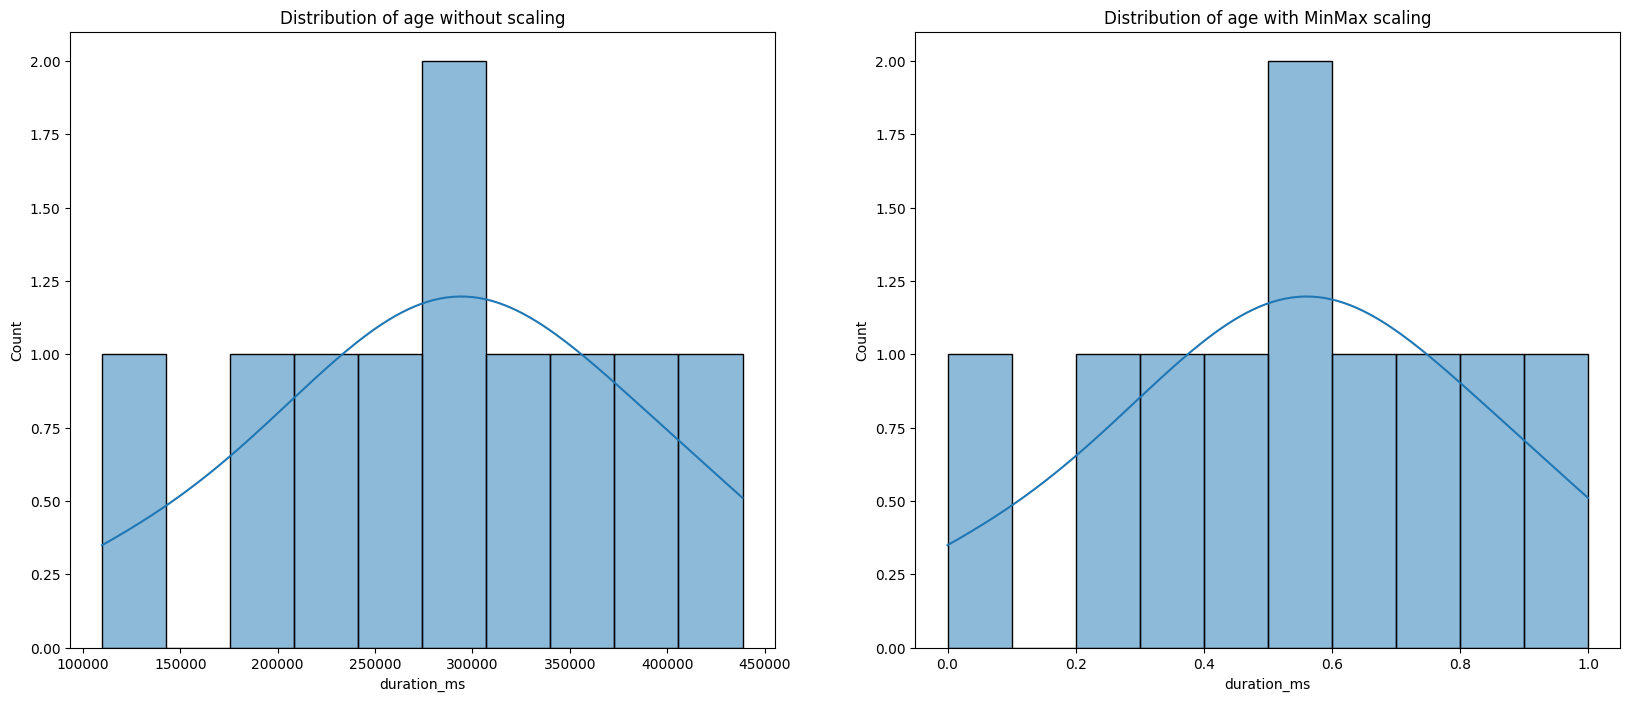

In [21]:
# Stating that we want two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plotting the two plots
sns.histplot(data=df.iloc[:,-2], bins=10, kde=True, ax=ax1);
sns.histplot(trans_scaler_1.iloc[:,-2], bins=10, kde=True, ax=ax2);

# Adding titles to the plots
ax1.set_title('Distribution of age without scaling')
ax2.set_title('Distribution of age with MinMax scaling')

plt.show()

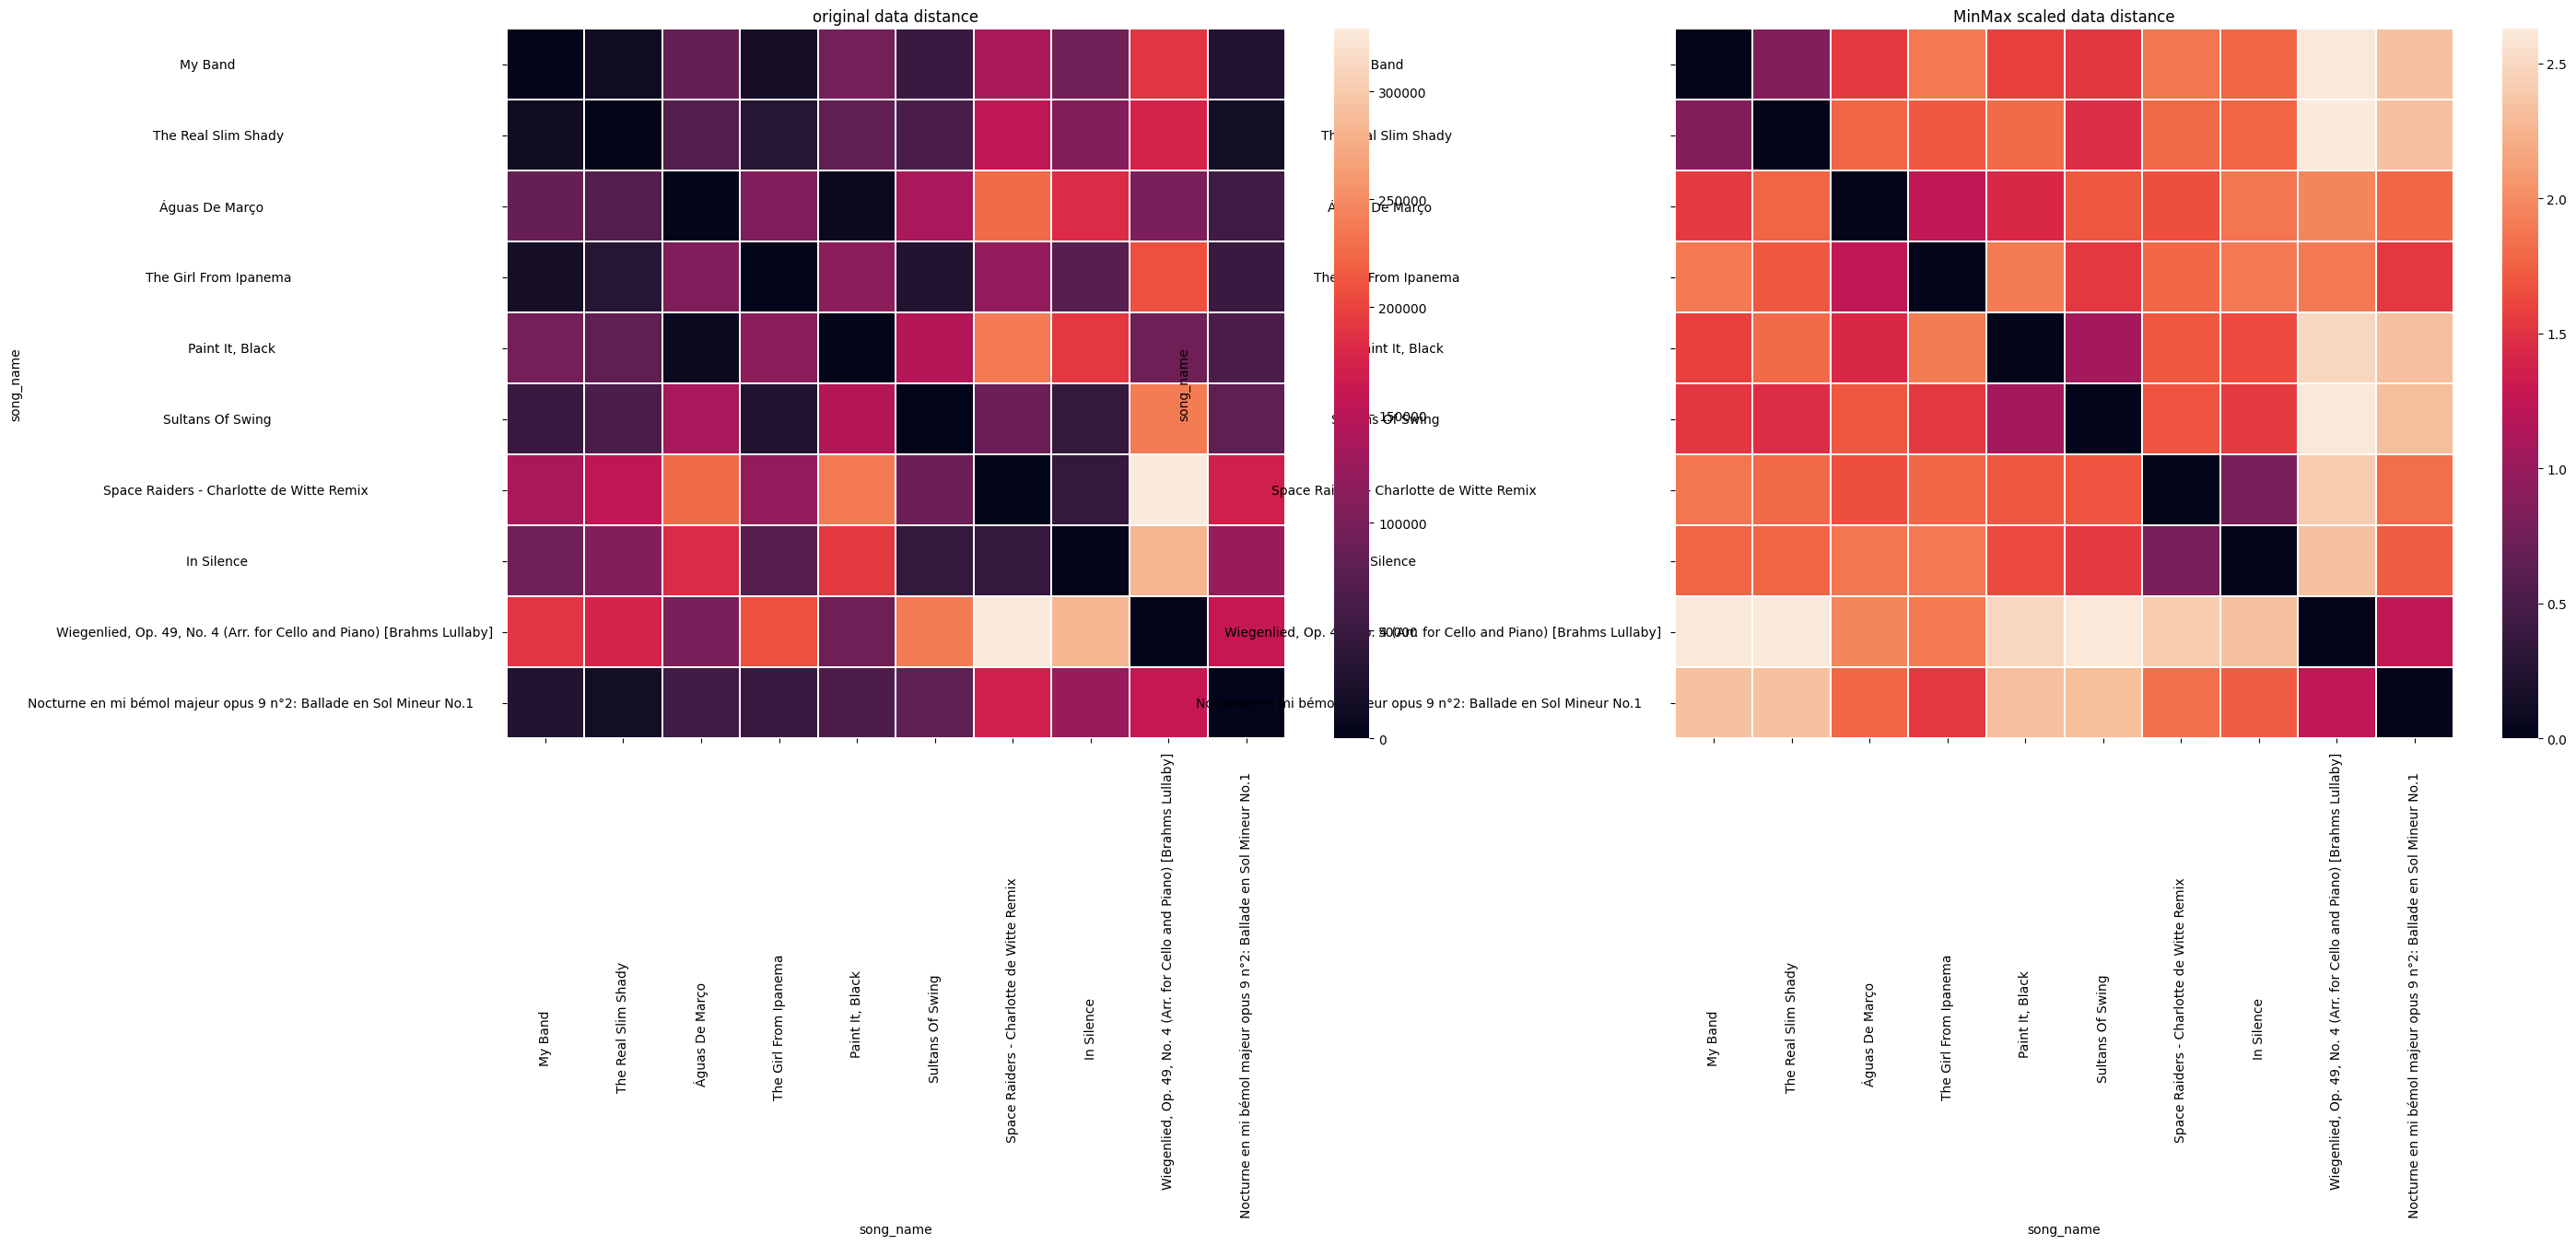

In [22]:
# comparing original data distance vs. with MinMax scaled data distance
# Making the DataFrame for the MinMaxed heatmap
pairwise_minmax_dis = pd.DataFrame(pairwise_distances(trans_scaler_1),
                                         index=df.index,
                                         columns=df.index)

# Stating that we want two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))

# Plotting the two plots
sns.heatmap(pairwise_dis_df, ax=ax1, linewidths=.2);
sns.heatmap(pairwise_minmax_dis, ax=ax2, linewidths=.2);

# Adding titles to the plots
ax1.set_title('original data distance')
ax2.set_title('MinMax scaled data distance')

plt.show()

* Standard scaler

In [23]:
scaler_2 = StandardScaler()

In [24]:
trans_scaler_2 = scaler_2.fit_transform(df)

In [25]:
trans_scaler_2

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
song_name,,,,,,,,,,,,,
My Band,1.000384,0.992687,-1.138990,1.217434,-2.0,0.435538,0.146786,-0.816077,-0.349827,1.270021,0.040646,0.123210,0.333333
The Real Slim Shady,1.451340,0.424153,0.759326,1.118976,-2.0,-0.299450,-0.952202,-0.816082,-1.002517,0.994657,-0.445036,-0.035980,0.333333
Águas De Março,0.038653,-0.549612,-0.189832,-0.168522,0.5,2.077778,0.987271,-0.816082,-0.451521,0.112834,0.773521,-0.820299,0.333333
The Girl From Ipanema,0.034052,-1.151411,2.183063,-0.315694,0.5,-0.821981,1.017877,-0.811999,-0.451521,-0.224816,0.331992,0.333097,0.333333
"Paint It, Black",-0.780429,0.829385,-1.138990,0.544582,0.5,0.716901,-0.907235,-0.810080,2.266479,0.509490,1.251782,-0.930989,0.333333
Sultans Of Swing,0.457397,0.826361,0.759326,0.458132,0.5,-1.060278,-0.878748,-0.725811,1.628581,1.555220,0.922451,0.667766,0.333333
Space Raiders - Charlotte de Witte Remix,0.531023,0.635842,0.284747,0.361846,0.5,1.159042,-1.015909,1.316484,-0.396051,-1.300705,0.415883,1.651944,0.333333
In Silence,0.471202,0.980591,-1.138990,0.230112,0.5,-0.859305,-1.010400,1.400114,-0.396051,-0.847664,0.291002,1.160598,0.333333
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",-2.068872,-1.549596,-0.189832,-2.226872,0.5,-0.451616,1.305102,0.649903,-0.460766,-0.805048,-1.790384,-1.941067,-3.000000


In [26]:
pd.DataFrame({'original': df.iloc[:, -2],
 'min_max_scaler': trans_scaler_2.iloc[:, -2]}).sort_values(by='original')

,original,min_max_scaler
song_name,,
"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and Piano) [Brahms Lullaby]",109800,-1.941067
"Paint It, Black",202267,-0.930989
Águas De Março,212400,-0.820299
Nocturne en mi bémol majeur opus 9 n°2: Ballade en Sol Mineur No.1,268427,-0.208279
The Real Slim Shady,284200,-0.035980
My Band,298773,0.123210
The Girl From Ipanema,317987,0.333097
Sultans Of Swing,348624,0.667766
In Silence,393740,1.160598


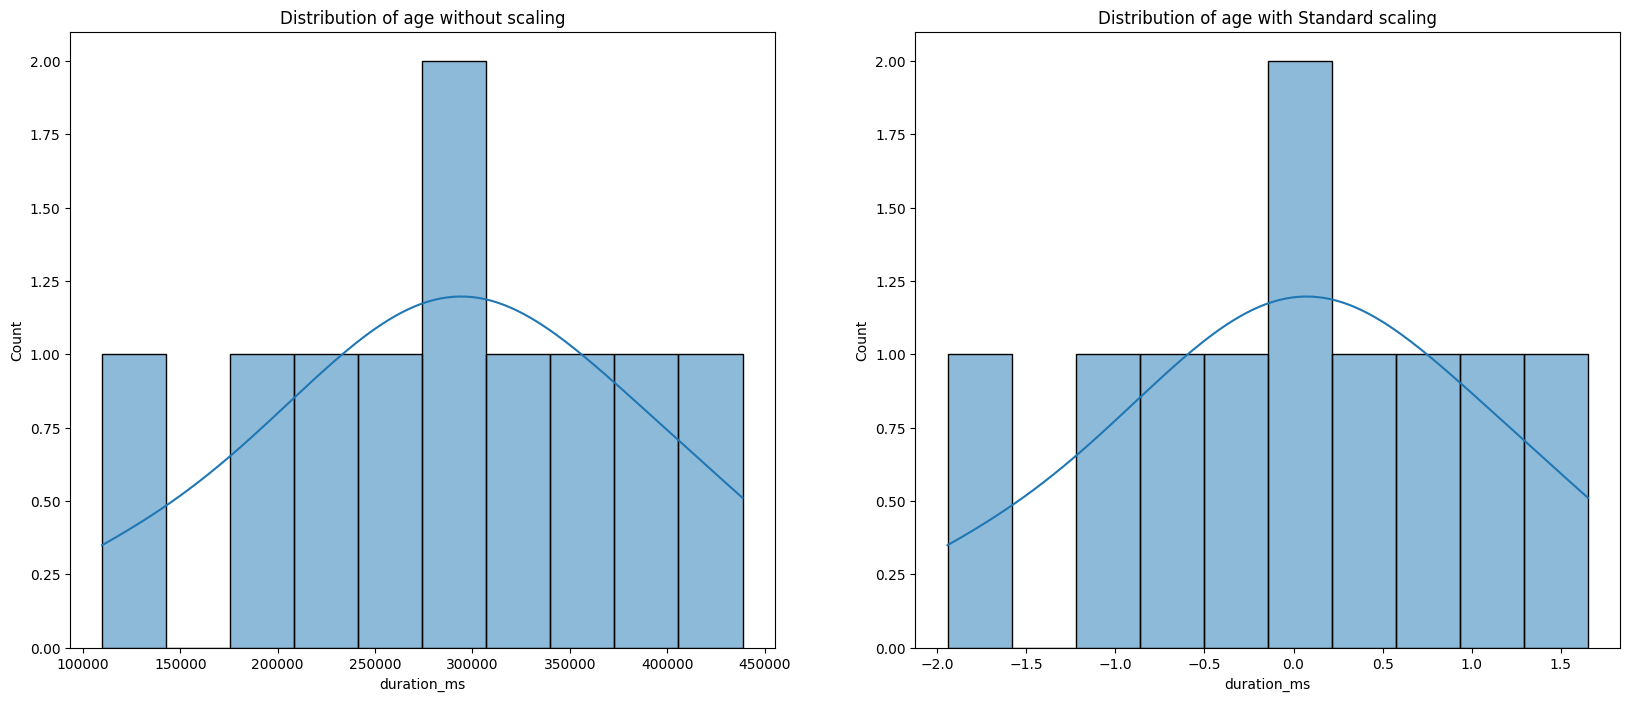

In [27]:
# Stating that we want two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plotting the two plots
sns.histplot(data=df.iloc[:,-2], bins=10, kde=True, ax=ax1);
sns.histplot(trans_scaler_2.iloc[:,-2], bins=10, kde=True, ax=ax2);

# Adding titles to the plots
ax1.set_title('Distribution of age without scaling')
ax2.set_title('Distribution of age with Standard scaling')

plt.show()

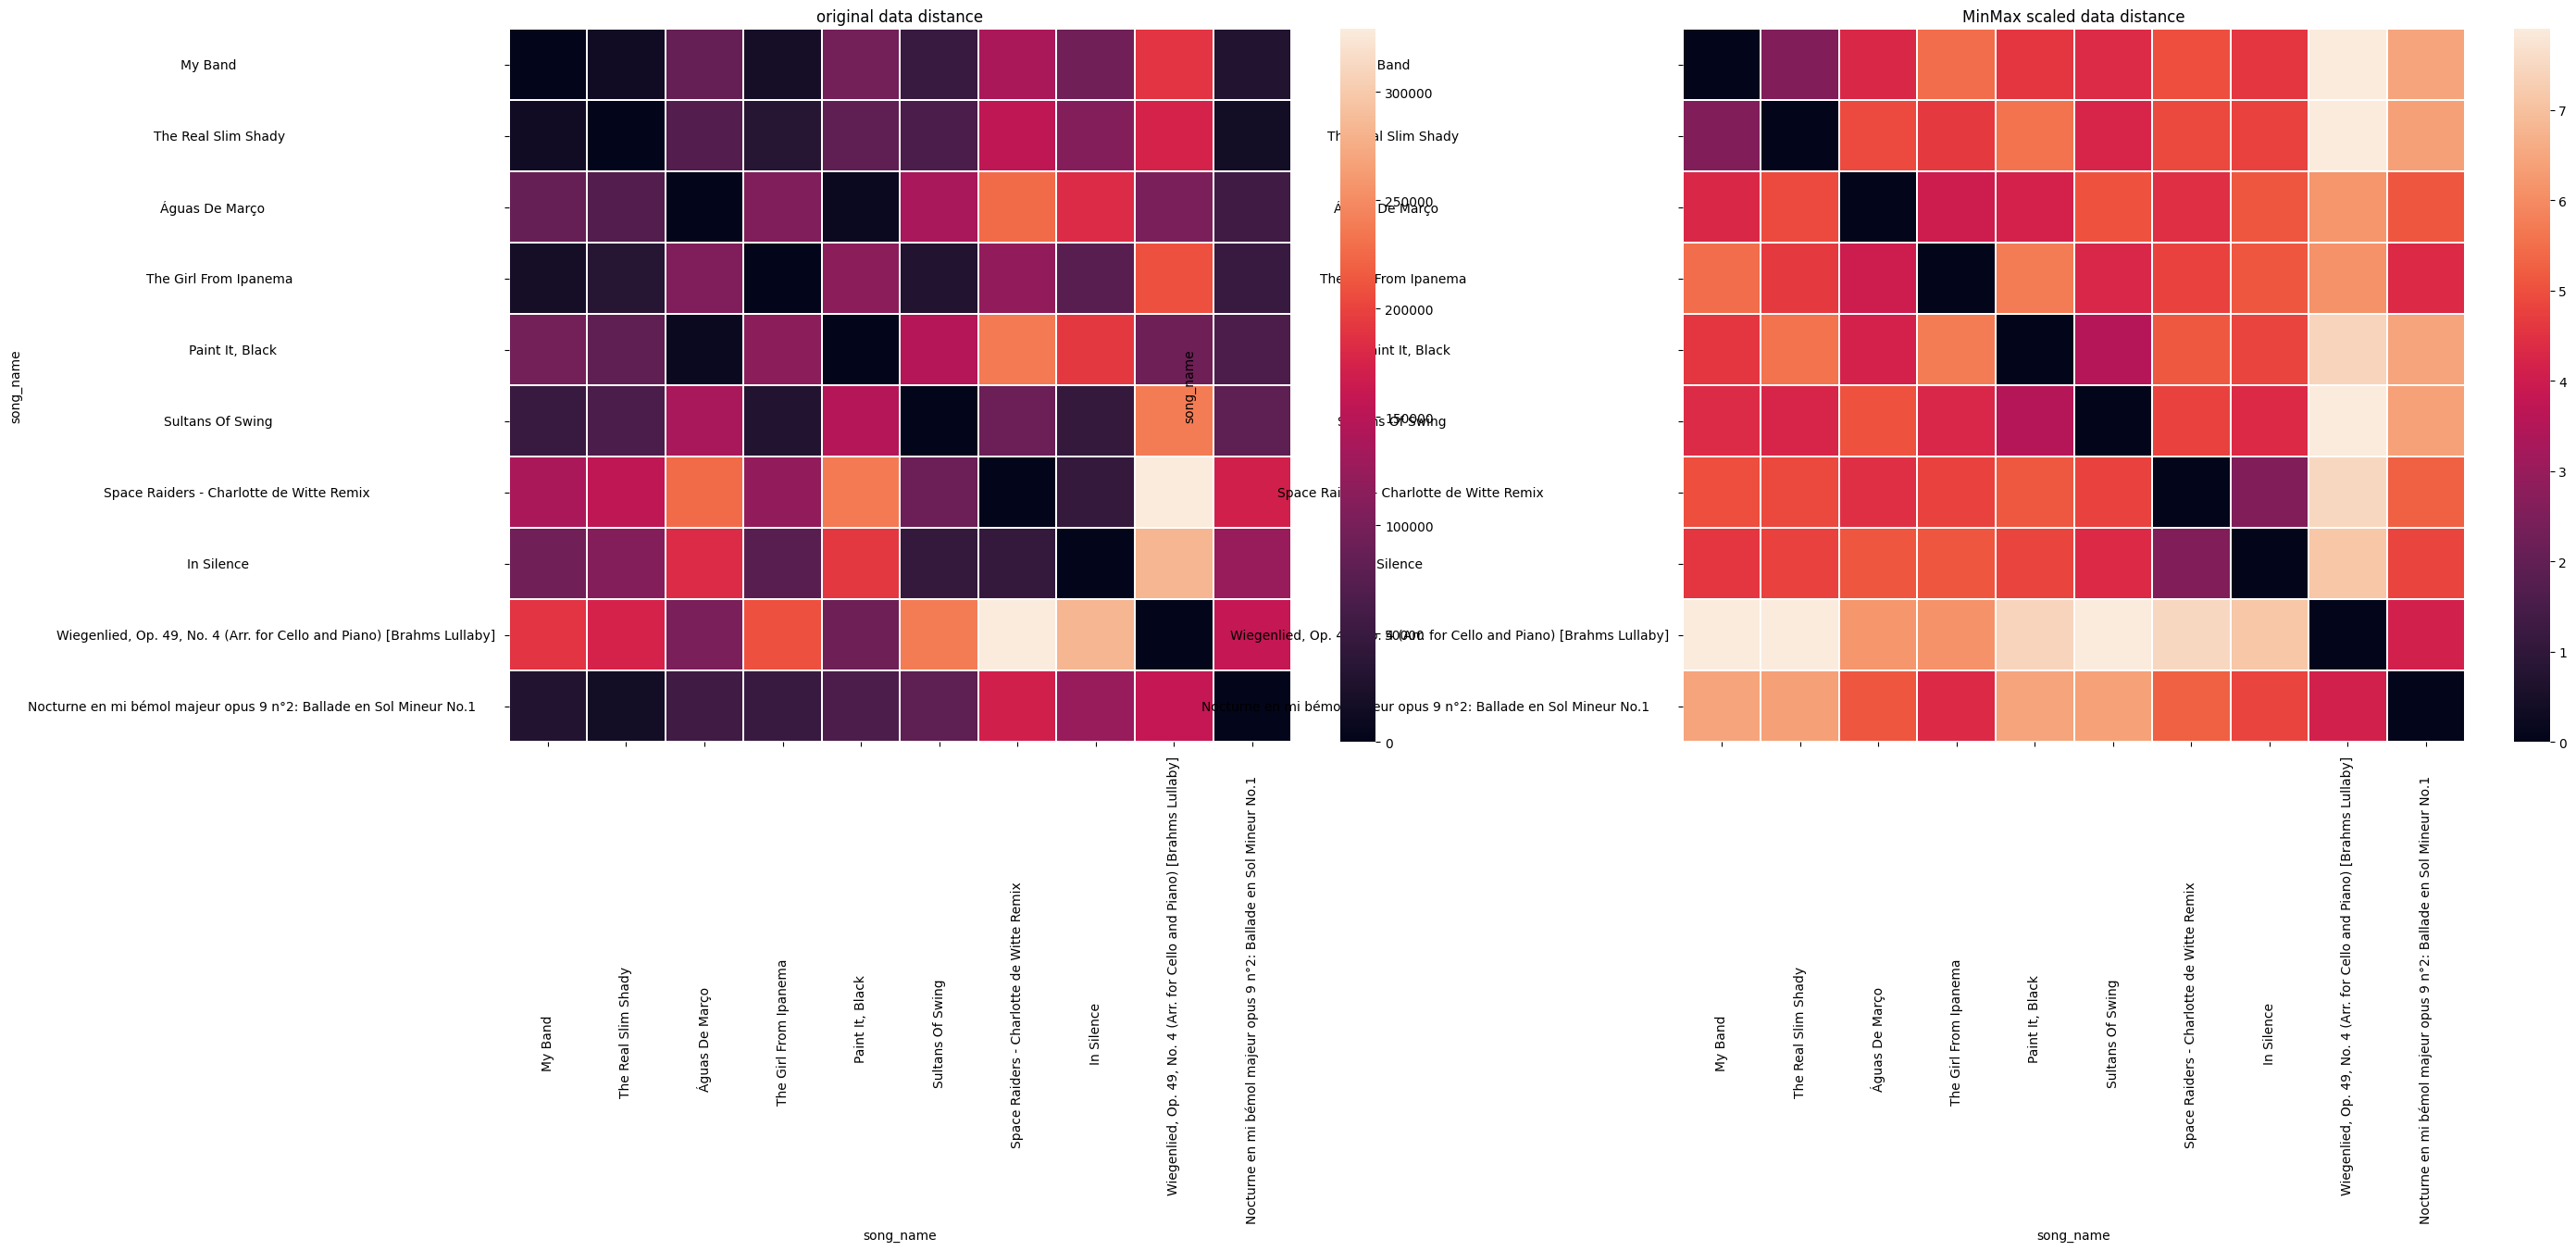

In [28]:
# comparing original data distance vs. with MinMax scaled data distance
# Making the DataFrame for the MinMaxed heatmap
pairwise_standard_dis = pd.DataFrame(pairwise_distances(trans_scaler_2),
                                         index=df.index,
                                         columns=df.index)

# Stating that we want two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))

# Plotting the two plots
sns.heatmap(pairwise_dis_df, ax=ax1, linewidths=.2);
sns.heatmap(pairwise_standard_dis, ax=ax2, linewidths=.2);

# Adding titles to the plots
ax1.set_title('original data distance')
ax2.set_title('MinMax scaled data distance')

plt.show()

In [29]:
from sklearn.cluster import KMeans
standard_obj = KMeans(n_clusters=3, random_state=10)
standard_obj.fit(trans_scaler_2)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=3, random_state=10)

In [30]:
standard_obj.labels_

array([2, 2, 2, 1, 2, 2, 0, 0, 1, 1], dtype=int32)

In [31]:
minmax_obj = KMeans(n_clusters=3, random_state=10)
minmax_obj.fit(trans_scaler_1)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=3, random_state=10)

In [32]:
minmax_obj.labels_

array([1, 1, 1, 0, 1, 1, 2, 2, 0, 0], dtype=int32)

* I will continue with exploring transformers and fit them in KMeans

# Scaling 5000 spotify songs

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer
from sklearn import set_config
set_config(transform_output = "pandas")
from sklearn.cluster import KMeans

In [3]:
# Read the CSV file
df_5 = pd.read_csv('/Users/samaardi/Desktop/WBS-Data Science Bootcamp/unsupervised machine learning/3_spotify_5000_songs.csv')

In [4]:
df_5.sample(20)

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
2850,2850,We'll Be Coming Back (feat. Example) ...,Calvin Harris,0.5960,0.9520,7,-4.364,1,0.0873,0.001310,0.000000,0.5980,0.5710,127.945,,234360,4,7B1Dl3tXqySkB8OPEwVvSu,https://open.spotify.com/track/7B1Dl3tXqySkB8O...
4343,4343,13th Moon ...,Seance,0.2740,0.9870,10,-7.013,0,0.1510,0.000039,0.795000,0.2950,0.1360,120.865,,161000,4,0sZE0DZfFOs6TVoxKbxqxi,https://open.spotify.com/track/0sZE0DZfFOs6TVo...
826,826,It Doesn't Matter Anymore ...,Buddy Holly,0.6650,0.1790,7,-16.727,1,0.0367,0.806000,0.000000,0.1890,0.8560,115.203,,124000,4,7KGbqCYWaXdJxhsuilkcwF,https://open.spotify.com/track/7KGbqCYWaXdJxhs...
2273,2273,Get Ur Freak On ...,Missy Elliott,0.7800,0.7870,0,-6.653,1,0.2090,0.533000,0.134000,0.1220,0.6680,177.835,,237067,4,0pcYJDuIsIzfOek0CIQdkm,https://open.spotify.com/track/0pcYJDuIsIzfOek...
1677,1677,My Love ...,Justin Timberlake,0.7710,0.6760,4,-6.018,0,0.2230,0.285000,0.000004,0.5460,0.8040,119.997,,276160,4,0gs72Zn1Nxin1kvKpo9ee5,https://open.spotify.com/track/0gs72Zn1Nxin1kv...
768,768,Bumpy Ride ...,Mohombi,0.7090,0.8540,0,-4.447,0,0.0399,0.047000,0.000000,0.0724,0.8260,105.074,,224402,4,0tBRo4P60DgKmg4jt48upm,https://open.spotify.com/track/0tBRo4P60DgKmg4...
4453,4453,Purveyor of Fear ...,Hellwitch,0.3310,0.9870,6,-7.486,1,0.1290,0.000163,0.059700,0.1710,0.1760,120.825,,224667,3,2Czu05aAtixZN9RhysOoQc,https://open.spotify.com/track/2Czu05aAtixZN9R...
1536,1536,Pon de Replay ...,Rihanna,0.7790,0.6400,7,-8.415,1,0.1590,0.000155,0.000770,0.1010,0.4980,99.019,,246960,4,4TsmezEQVSZNNPv5RJ65Ov,https://open.spotify.com/track/4TsmezEQVSZNNPv...
1019,1019,Do You Believe in Magic? ...,The Lovin' Spoonful,0.5530,0.7380,0,-7.963,1,0.0457,0.213000,0.000000,0.3390,0.7590,138.602,,125827,4,1udKn1oNKYQSQ9OmiIWCMu,https://open.spotify.com/track/1udKn1oNKYQSQ9O...
1592,1592,Sk8er Boi ...,Avril Lavigne,0.4870,0.9000,0,-4.417,1,0.0482,0.000068,0.000000,0.3580,0.4840,149.937,,204000,4,4omisSlTk6Dsq2iQD7MA07,https://open.spotify.com/track/4omisSlTk6Dsq2i...


In [5]:
df_5.columns = df_5.columns.str.strip()

In [6]:
df_5.columns

Index(['Unnamed: 0', 'name', 'artist', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'type', 'duration_ms', 'time_signature',
       'id', 'html'],
      dtype='object')

In [7]:
df_5.drop(columns=['Unnamed: 0', 'type', 'duration_ms', 'id', 'html'], inplace=True)

In [8]:
df_5.set_index(['name', 'artist'], inplace=True)

In [9]:
minmax_scaler = MinMaxScaler()
# we fit and transform our data to minmax scaler to see the correlation after eliminating some columns
df_5_scaled = minmax_scaler.fit_transform(df_5)

In [11]:
from sklearn.decomposition import PCA
my_dv = PCA(n_components=1)
dance_val = my_dv.fit_transform(df_5_scaled[['danceability', 'valence']])

In [12]:
dance_val

,,pca0
name,artist,
Se Eu Quiser Falar Com Deus,Gilberto Gil,-0.023352
Saudade De Bahia,Antônio Carlos Jobim,0.346032
"Canta Canta, Minha Gente",Martinho Da Vila,0.586512
Mulher Eu Sei,Chico César,0.184532
Rosa Morena,Kurt Elling,0.051426
...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,-0.497364
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,-0.530532
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,-0.609171


In [13]:
my_dv_2 = PCA(n_components=1)
loud_energy_acc = my_dv_2.fit_transform(df_5_scaled[['loudness', 'energy', 'acousticness']])

In [14]:
loud_energy_acc

,,pca0
name,artist,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.564610
Saudade De Bahia,Antônio Carlos Jobim,0.106964
"Canta Canta, Minha Gente",Martinho Da Vila,0.085489
Mulher Eu Sei,Chico César,0.849554
Rosa Morena,Kurt Elling,0.841555
...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.882746
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.810941
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,1.007256


In [15]:
df_5_scaled['danceability_valence'] = dance_val

In [16]:
df_5_scaled['acoustic_loudness_energy'] = loud_energy_acc

In [17]:
df_5_scaled.drop(columns=['danceability', 'valence', 'energy', 'acousticness', 'loudness'], inplace=True)

In [18]:
df_5_scaled

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy
name,artist,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,1.000000,0.0,0.076797,0.000060,0.987842,0.515800,0.8,-0.023352,0.564610
Saudade De Bahia,Antônio Carlos Jobim,0.181818,1.0,0.037691,0.000002,0.108409,0.584322,0.8,0.346032,0.106964
"Canta Canta, Minha Gente",Martinho Da Vila,0.181818,1.0,0.377996,0.000064,0.125633,0.437862,0.8,0.586512,0.085489
Mulher Eu Sei,Chico César,0.363636,1.0,0.051307,0.000041,0.391084,0.499098,0.8,0.184532,0.849554
Rosa Morena,Kurt Elling,0.545455,1.0,0.041394,0.000348,0.105370,0.565171,0.8,0.051426,0.841555
...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.272727,1.0,0.051525,0.725888,0.084296,0.410795,0.8,-0.497364,0.882746
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.545455,1.0,0.048148,0.432487,0.070314,0.388495,0.8,-0.530532,0.810941
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.818182,1.0,0.047277,0.983756,0.078217,0.334469,0.6,-0.609171,1.007256


In [19]:
df_5_scaled.corr()

,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy
key,1.000000,-0.155697,0.027547,-0.016775,0.025193,-0.002370,0.007796,-0.011586,-0.027927
mode,-0.155697,1.000000,-0.041282,-0.003017,-0.009712,0.004739,-0.013039,-0.031172,0.022326
speechiness,0.027547,-0.041282,1.000000,-0.064754,0.081963,0.064255,0.060871,0.006501,-0.291437
instrumentalness,-0.016775,-0.003017,-0.064754,1.000000,-0.051664,-0.071945,-0.160122,-0.571519,0.205323
liveness,0.025193,-0.009712,0.081963,-0.051664,1.000000,0.036370,0.025039,-0.007911,-0.135373
tempo,-0.002370,0.004739,0.064255,-0.071945,0.036370,1.000000,0.024075,0.064059,-0.206786
time_signature,0.007796,-0.013039,0.060871,-0.160122,0.025039,0.024075,1.000000,0.215361,-0.172970
danceability_valence,-0.011586,-0.031172,0.006501,-0.571519,-0.007911,0.064059,0.215361,1.000000,-0.146330
acoustic_loudness_energy,-0.027927,0.022326,-0.291437,0.205323,-0.135373,-0.206786,-0.172970,-0.146330,1.000000


<Axes: >

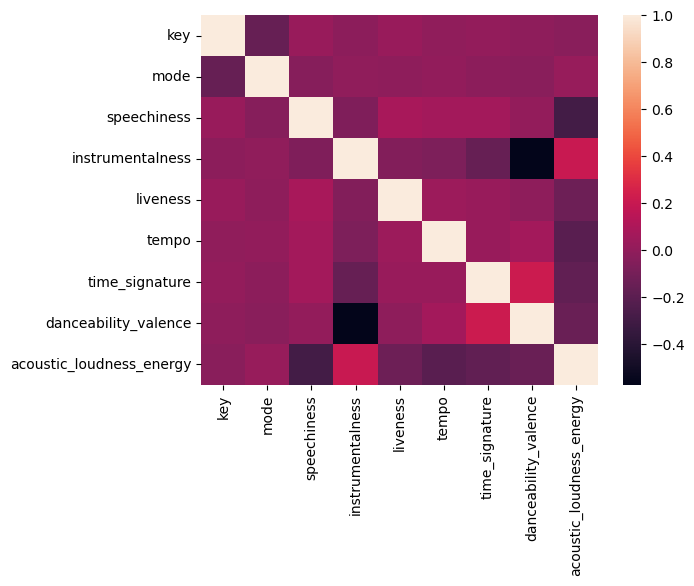

In [20]:
sns.heatmap(df_5_scaled.corr())

## importing ydata_profiling to get insights about our data

In [7]:
!pip install ydata_profiling

  Obtaining dependency information for ydata_profiling from https://files.pythonhosted.org/packages/33/85/45027914eb485482976883dcaab434eab99f1ed5cb222781e7ba46bdf3b7/ydata_profiling-4.8.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for pydantic>=2 from https://files.pythonhosted.org/packages/ed/76/9a17032880ed27f2dbd490c77a3431cbc80f47ba81534131de3c2846e736/pydantic-2.7.1-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.3/107.3 kB 3.9 MB/s eta 0:00:00
  Obtaining dependency information for visions[type_image_path]<0.7.7,>=0.7.5 from https://files.pythonhosted.org/packages/7c/bf/612b24e711ae25dea9af19b9304634b8949faa0b035fad47e8bcadf62f59/visions-0.7.6-py3-none-any.whl.metadata
  Preparing metadata (setup.py) ... done
  Obtaining dependency information for phik<0.13,>=0.11.1 from https://files.pythonhosted.org/packages/b9/69/a42d9320b68b0d43d78db46787669b2287cba5e8db2e83fe0d63c1fd6945/phik-0.12.4-cp311-cp311-macosx_11_0_arm64.whl.metadata


In [8]:
from ydata_profiling import ProfileReport

In [699]:
ProfileReport(df_5_scaled)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [501]:
df_5.columns

Index(['Unnamed: 0', 'name', 'artist', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'type', 'duration_ms', 'time_signature',
       'id', 'html'],
      dtype='object')

In [12]:
#pairwise_df_5 = pd.DataFrame(pairwise_distances(df_5),
                             #index=df_5.index,
                             #columns=df_5.index)

# Stating that we want two plots. we use pairedwise df to plot our heatmap
#fig, ax = plt.subplots(1, figsize=(20, 8))

#sns.heatmap(pairwise_df_5, ax=ax, linewidths=.2);

#ax.set_title('pairwise distance')
#plt.show()

In [590]:
columns = list(m_transformed.columns)
variance = []
for i in columns:
    variance.append(m_transformed[i].var())

In [591]:
variance

[0.05084209892360379,
 0.08313704589669817,
 0.010530643915136317,
 0.12774503947459473,
 0.0794983357996381]

## inertia method

In [55]:
seed = 42
max_k = 100
inertia_list=[]

for i in range(10, max_k + 1):
  df_5_kmean = KMeans(n_clusters= i,
                      n_init = "auto",
                    random_state= seed
                    )
  df_5_kmean.fit(df_5_scaled)
  inertia_list.append(df_5_kmean.inertia_)

In [56]:
inertia_list

[12822.27646129455,
 10387.16468174717,
 9379.577284323183,
 8887.212076158114,
 7422.498194601173,
 6769.702085047144,
 6379.165851718642,
 5828.303625278455,
 5593.988344787967,
 4869.810714314564,
 4374.722081947642,
 4376.987466112968,
 4014.1629433254357,
 3732.4150754673283,
 3404.450658834251,
 3298.3946620937554,
 3092.6560322036476,
 2898.130004721803,
 2698.507023831542,
 2415.1101824383586,
 2208.2648423972073,
 2057.938394886599,
 1863.3803240622412,
 1724.2836361847867,
 1603.3355598719147,
 1484.5963910643147,
 1351.3761605810241,
 1227.2553430481912,
 1156.8191172016375,
 1074.5814069915457,
 976.7946233652561,
 892.0576762729083,
 789.0062111317953,
 709.2447169779832,
 641.1419666855448,
 576.1423320871767,
 536.2813750741636,
 534.0257320340957,
 530.7593988878176,
 528.9153324496585,
 526.6435292927808,
 524.7935770180543,
 522.7842969998976,
 518.0516676376405,
 516.6837327909047,
 513.0214131022402,
 509.2107699667447,
 507.234823983181,
 505.58297424588505,
 504.1

/Users/samaardi/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


()

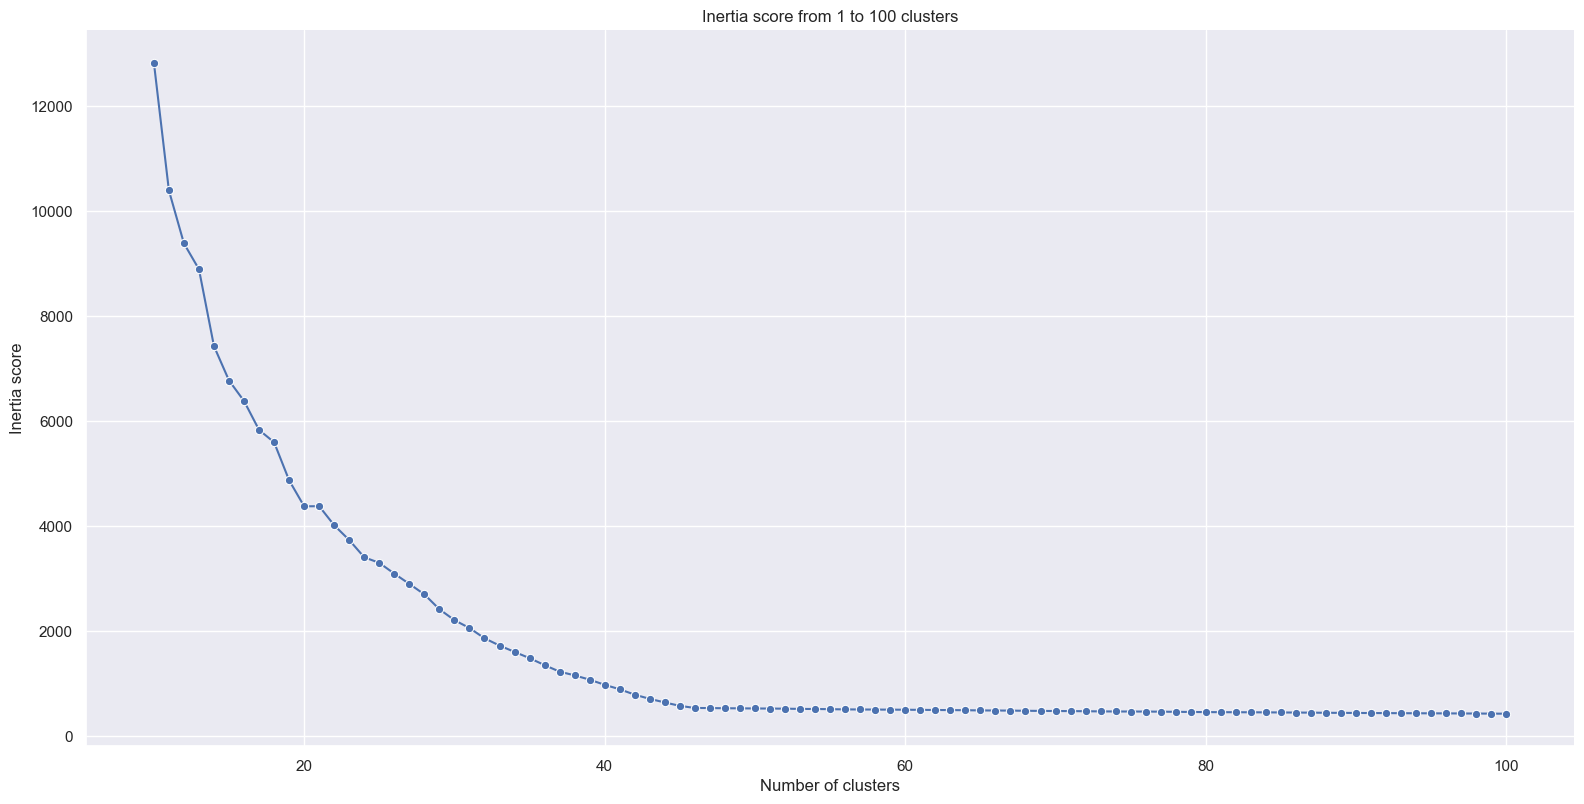

In [57]:
# Set the Seaborn theme to darkgrid
sns.set_theme(style='darkgrid')
%matplotlib inline
(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(10, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from 1 to {max_k} clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);()

## The silhouette coefficient

In [24]:
from sklearn.metrics import silhouette_score

In [58]:
max_k = 100
sil_list = []
for j in range(10, max_k + 1):
  s_kmeans = KMeans(n_clusters=j,
             n_init = "auto",
             random_state=seed)
  s_kmeans.fit(df_5_scaled)
  labels = s_kmeans.labels_
  score = silhouette_score(df_5_scaled, labels)
  sil_list.append(score)

/Users/samaardi/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


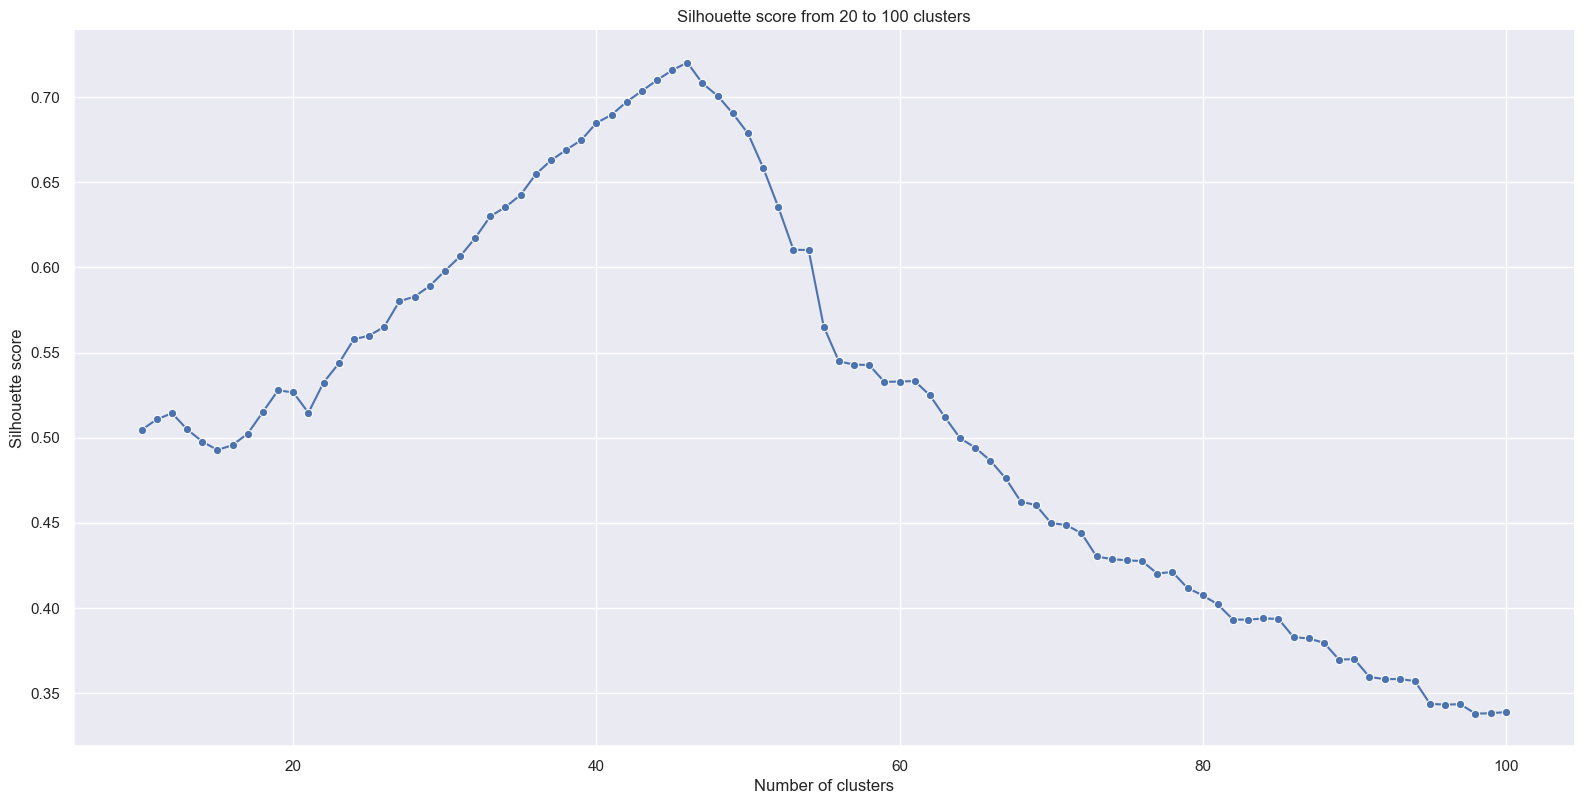

In [59]:
(
sns.relplot(y = sil_list,
            x = range(10, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 20 to {max_k } clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);

In [27]:
s_kmeans = KMeans(n_clusters=46,
             n_init = "auto",
             random_state=seed)

s_kmeans.fit(df_5_scaled)

KMeans(n_clusters=46, n_init='auto', random_state=42)

In [28]:
s_kmeans.labels_

array([30, 34, 34, ..., 16, 28, 28], dtype=int32)

In [29]:
df_5_scaled['cluster'] = s_kmeans.labels_

In [42]:
cluster_1 = df_5_scaled.loc[df_5_scaled['cluster'] == 0, :]

In [44]:
cluster_1.sample(15)

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
Porgy (I Loves You Porgy) - Outtake,Bill Evans Trio,0.454545,1.0,0.032789,0.889340,0.664640,0.465167,0.8,-0.314604,0.838037,0
Love Me Like You Do,Henry Smith,0.727273,1.0,0.059150,0.961421,0.126646,0.812094,0.8,-0.442523,0.846261,0
Perfect,The Piano Guys,0.727273,1.0,0.069608,0.920812,0.111449,0.837520,0.6,-0.269505,0.841729,0
Fairytail,Phoria,0.454545,1.0,0.048802,0.976650,0.241135,0.620950,0.6,-0.551875,0.817974,0
Cursed,Morgoth,0.818182,1.0,0.050980,0.858883,0.147923,0.582518,0.6,-0.483292,0.679164,0
Lily of the Valley,Eusebius,0.454545,1.0,0.043791,0.878173,0.112462,0.805954,0.6,-0.262914,0.907970,0
All of Me,Henry Smith,0.727273,1.0,0.049564,0.964467,0.119554,0.594953,0.8,-0.261615,0.925052,0
I Will Always Love You,David Schultz,0.818182,1.0,0.066013,0.946193,0.077102,0.609113,0.8,-0.146643,0.965223,0
Yesterday,David Schultz,0.454545,1.0,0.067865,0.937056,0.113475,0.762695,0.8,-0.341344,0.853493,0


In [45]:
cluster_2 = df_5_scaled.loc[df_5_scaled['cluster'] == 1, :]
cluster_2.sample(15)

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
In Sufferance,Disincarnate,0.818182,1.0,0.126362,0.100000,0.108409,0.405556,0.8,-0.486484,-0.410881,1
Bullshit Propaganda,Extreme Noise Terror,0.545455,1.0,0.072985,0.098579,0.279635,0.495850,0.8,-0.285198,-0.375755,1
From The Valley Of Shadows,Mortification,0.818182,1.0,0.074510,0.057462,0.166160,0.482186,0.8,-0.301115,-0.414217,1
Pyramids,DVBBS,0.909091,1.0,0.053050,0.038477,0.062918,0.598355,0.8,-0.075396,-0.431103,1
Body Count,Morgoth,0.909091,1.0,0.116558,0.000000,0.105370,0.718590,0.8,-0.507444,-0.437402,1
"No Jesus, No Beast",Immolation,0.636364,1.0,0.100436,0.065482,0.619048,0.391785,0.8,-0.420128,-0.382350,1
Blood Bath,Cancer,0.818182,1.0,0.070915,0.349239,0.048024,0.531053,1.0,-0.291579,-0.396394,1
Eaten,Bloodbath,0.909091,1.0,0.062745,0.000000,0.104357,0.691616,0.8,-0.264199,-0.430498,1
Tears,Desultory,0.727273,1.0,0.184096,0.016548,0.336373,0.506253,0.8,-0.215142,-0.405446,1


In [46]:
cluster_3 = df_5_scaled.loc[df_5_scaled['cluster'] == 2, :]
cluster_3.sample(15)

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
Come Go With Me,The Del-Vikings,0.454545,0.0,0.044553,0.000000,0.089463,0.606056,0.8,0.148120,0.401981,2
Mad Love,Mabel,0.000000,0.0,0.187364,0.000000,0.107396,0.923898,0.8,0.213299,0.188845,2
High Up,Jonathan Traylor,0.454545,0.0,0.075163,0.000000,0.097264,0.663269,0.8,0.217047,0.180867,2
Hipsippy Blues,Art Blakey & The Jazz Messengers,0.454545,0.0,0.068301,0.000057,0.104357,0.645983,0.8,0.170465,0.604419,2
Eternal Flame,The Bangles,0.363636,0.0,0.026471,0.000000,0.095441,0.369125,0.6,-0.026719,0.355983,2
Autumn Leaves,Chet Baker,0.454545,0.0,0.039651,0.408122,0.075583,0.436268,0.8,0.125495,0.395397,2
I Need A Girl PT II,Diddy,0.090909,0.0,0.526144,0.000000,0.031206,0.933492,0.8,0.401511,0.206974,2
Stormy Weather,Etta James,0.000000,0.0,0.033007,0.000000,0.177305,0.813945,0.6,-0.164322,0.427997,2
"Mrs. Robinson - From ""The Graduate"" Soundtrack",Simon & Garfunkel,0.545455,0.0,0.054139,0.000026,0.075684,0.430081,0.8,0.362466,0.461991,2


In [47]:
cluster_4 = df_5_scaled.loc[df_5_scaled['cluster'] == 3, :]
cluster_4.sample(15)

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
Without You (feat. Usher),David Guetta,0.181818,1.0,0.031046,0.000004,0.159068,0.597617,0.8,0.025393,-0.041318,3
Wichita Lineman - Remastered 2001,Glen Campbell,0.454545,1.0,0.035730,0.000202,0.251266,0.805234,0.8,-0.235508,0.193240,3
Da Doo Ron Ron (When He Walked Me Home),The Crystals,0.272727,1.0,0.050000,0.000035,0.142857,0.695523,0.8,0.154868,0.055750,3
Kogong,Mark Forster,0.090909,1.0,0.068519,0.000702,0.132725,0.607926,0.8,0.122115,-0.007839,3
Rette Mich,Tokio Hotel,0.181818,1.0,0.034096,0.000000,0.129686,0.560559,0.8,-0.303729,-0.042354,3
Always Be My Baby,Mariah Carey,0.363636,1.0,0.039651,0.000000,0.252280,0.368924,0.8,0.120781,0.201365,3
He's a Doll,The Honeys,0.090909,1.0,0.046623,0.000000,0.178318,0.711982,0.8,0.206225,0.182637,3
To Sir with Love,Lulu,0.363636,1.0,0.029412,0.000003,0.100811,0.453956,0.8,-0.095272,0.209633,3
Hey,Andreas Bourani,0.090909,1.0,0.041503,0.000000,0.104357,0.634829,0.8,-0.273219,0.433316,3


In [48]:
cluster_5 = df_5_scaled.loc[df_5_scaled['cluster'] == 4, :]
cluster_5.sample(15)

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
The Deceived Ones,Opprobrium,0.727273,0.0,0.156863,0.001503,0.196555,0.636446,0.8,-0.499309,-0.441454,4
Dusk Till Dawn - Radio Edit,ZAYN,1.000000,0.0,0.042484,0.000001,0.107396,0.841362,0.8,-0.437782,-0.023867,4
Deep In Your Subconcious,Atrocity,0.727273,0.0,0.176471,0.016853,0.097366,0.638820,0.8,-0.463683,-0.447978,4
Cleansed Of Impurity,Solstice,0.727273,0.0,0.159041,0.000771,0.310030,0.499827,0.8,-0.289973,-0.446633,4
You,Galantis,0.727273,0.0,0.072004,0.169543,0.151976,0.598028,0.8,-0.389327,-0.368677,4
Cause of Death,Obituary,0.818182,0.0,0.149237,0.007655,0.122594,0.657778,0.8,-0.450190,-0.426480,4
Punish My Heaven,Dark Tranquillity,0.727273,0.0,0.179739,0.033299,0.041844,0.620286,0.8,-0.404333,-0.444807,4
Razor Divine,Deranged,1.000000,0.0,0.252723,0.084264,0.673759,0.583644,0.8,-0.535962,-0.446191,4
Arise,Sepultura,0.818182,0.0,0.101416,0.055635,0.092806,0.538978,0.8,-0.317488,-0.419553,4


In [32]:
cluster_1.shape

(172, 10)

In [35]:
cluster_27 = df_5_scaled.loc[df_5_scaled['cluster'] == 26, :]
cluster_27.sample(20)

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
Helium - Piano Version,Sia Furler,0.363636,1.0,0.039542,0.874112,0.143870,0.650839,0.8,-0.374845,0.936147,26
Someone You Loved - Piano Version,Flying Fingers,0.090909,1.0,0.054139,0.907614,0.108409,0.509790,0.8,-0.294905,0.774016,26
Someone You Loved,The Piano Guys,0.090909,1.0,0.039107,0.954315,0.108409,0.464639,0.8,-0.419570,0.839515,26
Prelude No. 1 in C Major,Dmitri Shostakovich,0.000000,1.0,0.078867,0.938071,0.062107,0.755933,0.8,-0.378999,1.016239,26
At Last (Solo Piano Version),Alexis Ffrench,0.090909,1.0,0.045752,0.929949,0.092503,0.822721,0.8,-0.296095,0.876862,26
Russian Snow,Lucette Bourdin,0.000000,1.0,0.046187,0.948223,0.098784,0.659437,0.8,-0.530585,0.938402,26
Imagine,2CELLOS,0.000000,1.0,0.041503,0.874112,0.095238,0.594093,0.8,-0.082722,0.810536,26
Sleep,Goldbæk,0.181818,1.0,0.055556,0.921827,0.101317,0.346656,0.8,-0.213421,0.931207,26
"Diabelli Variations - 33 Variations on a Waltz by Anton Diabelli, Op. 120: Var. 24 - Fughetta. Andante",Ludwig van Beethoven,0.000000,1.0,0.050000,0.885279,0.103343,0.356947,0.8,-0.245827,1.014057,26


In [37]:
cluster_19 = df_5_scaled.loc[df_5_scaled['cluster'] == 18, :]
cluster_19.sample(20)

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
Sexy Bitch (feat. Akon),David Guetta,1.000000,0.0,0.052941,0.000625,0.132725,0.607556,0.8,0.477907,-0.163028,18
Señorita,Shawn Mendes,0.818182,0.0,0.031590,0.000000,0.083891,0.546600,0.8,0.402416,-0.140824,18
Hips Don't Lie (feat. Wyclef Jean),Shakira,0.909091,0.0,0.077015,0.000000,0.410334,0.467424,0.8,0.421326,-0.117952,18
White Noise,Disclosure,0.909091,0.0,0.057190,0.001533,0.357649,0.560774,0.8,0.457357,-0.365098,18
You Make Me Feel Like Dancing - Remastered,Leo Sayer,0.727273,0.0,0.054575,0.000000,0.058663,0.448255,0.8,0.370479,-0.210566,18
That Don't Impress Me Much,Shania Twain,0.909091,0.0,0.055229,0.000000,0.143870,0.584163,1.0,0.570513,-0.262501,18
Mensch,Herbert Grönemeyer,1.000000,0.0,0.086819,0.001513,0.077812,0.813239,0.8,0.451276,-0.292767,18
Te la Tiro Pa Que Bailes,Dj Joe,0.727273,0.0,0.061765,0.000024,0.358663,0.429931,0.8,0.646984,-0.145675,18
No Se Si Fue,Arcangel,1.000000,0.0,0.096841,0.000459,0.084600,0.430076,0.8,0.486655,0.083604,18


In [38]:
cluster_41 = df_5_scaled.loc[df_5_scaled['cluster'] == 40, :]
cluster_41.sample(20)

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
White Rabbit (feat. Pep & Rash),Sander van Doorn,1.000000,0.0,0.032680,0.009259,0.121581,0.588803,0.8,0.283383,-0.410221,40
Prinzesschen,LaFee,0.818182,0.0,0.027233,0.000000,0.260385,0.654054,0.8,0.091777,-0.170335,40
La Playa,Myke Towers,0.909091,0.0,0.163399,0.000000,0.108409,0.654741,0.8,0.098878,-0.178594,40
Iris,The Goo Goo Dolls,1.000000,0.0,0.039434,0.000008,0.095441,0.728656,0.6,-0.073797,-0.265732,40
Sweet Nothing (feat. Florence Welch),Calvin Harris,0.727273,0.0,0.118736,0.000114,0.057447,0.597850,0.8,0.152358,-0.254954,40
Blackeye,Love Inks,1.000000,0.0,0.036166,0.003939,0.223911,0.578022,0.8,0.245460,-0.072657,40
Whatever You Like,T.I.,0.818182,0.0,0.077233,0.000000,0.264438,0.701215,0.8,0.122482,-0.242720,40
New Rules,Dua Lipa,0.818182,0.0,0.075599,0.000016,0.155015,0.542423,0.8,0.288178,-0.261509,40
Cold (feat. Future),Maroon 5,0.818182,0.0,0.123094,0.000000,0.042958,0.466868,0.8,0.164874,-0.180596,40


In [ ]:
df_5_scaled.drop(columns=[''])

In [726]:
s_kmeans.cluster_centers_

array([[ 6.65501166e-01,  1.00000000e+00,  5.11032903e-02,
         8.77482754e-01,  1.46742265e-01,  6.78510858e-01,
         7.28205128e-01, -3.27380777e-01,  8.48034631e-01],
       [ 7.65856237e-01,  1.00000000e+00,  1.31901378e-01,
         1.09820169e-01,  1.94726208e-01,  5.65339420e-01,
         7.73255814e-01, -3.42553893e-01, -3.97657707e-01],
       [ 2.49795250e-01,  0.00000000e+00,  9.56171858e-02,
         3.39633174e-02,  1.63354236e-01,  5.48614926e-01,
         7.81981982e-01,  1.86823275e-01,  3.88906044e-01],
       [ 1.70653907e-01,  1.00000000e+00,  5.48025838e-02,
         1.57755354e-02,  1.58308004e-01,  5.68465119e-01,
         7.85964912e-01, -3.76719299e-02,  1.49169001e-01],
       [ 9.00432900e-01,  0.00000000e+00,  1.25417574e-01,
         6.53216089e-02,  2.17301105e-01,  5.74734856e-01,
         7.83333333e-01, -2.90258309e-01, -3.69207664e-01],
       [ 2.50201126e-01,  1.11022302e-16,  4.87612547e-02,
         8.84910831e-01,  1.37044409e-01,  4.672766

In [609]:
len(s_kmeans.cluster_centers_)

47

In [457]:
centroid_1 = s_kmeans.cluster_centers_[0]

In [458]:
centroid_1

array([0.43063968, 0.03382301, 0.30426716, 0.50403093, 0.25208536,
       0.74285714])

### we do clutering again by PCR analysis to see if it changes 

In [727]:
df_5_scaled

,,key,mode,speechiness,instrumentalness,liveness,tempo,time_signature,danceability_valence,acoustic_loudness_energy,cluster
name,artist,,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,1.000000,0.0,0.076797,0.000060,0.987842,0.515800,0.8,-0.023352,0.564610,30
Saudade De Bahia,Antônio Carlos Jobim,0.181818,1.0,0.037691,0.000002,0.108409,0.584322,0.8,0.346032,0.106964,34
"Canta Canta, Minha Gente",Martinho Da Vila,0.181818,1.0,0.377996,0.000064,0.125633,0.437862,0.8,0.586512,0.085489,34
Mulher Eu Sei,Chico César,0.363636,1.0,0.051307,0.000041,0.391084,0.499098,0.8,0.184532,0.849554,20
Rosa Morena,Kurt Elling,0.545455,1.0,0.041394,0.000348,0.105370,0.565171,0.8,0.051426,0.841555,43
...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.272727,1.0,0.051525,0.725888,0.084296,0.410795,0.8,-0.497364,0.882746,28
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.545455,1.0,0.048148,0.432487,0.070314,0.388495,0.8,-0.530532,0.810941,12
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.818182,1.0,0.047277,0.983756,0.078217,0.334469,0.6,-0.609171,1.007256,16


In [728]:
df_5_scaled.drop('cluster', inplace=True)

In [ ]:
from sklearn.decomposition import PCA

In [570]:
my_pca = PCA(n_components = 2)

In [571]:
pca_variance_df = my_pca.fit_transform(m_transformed)

In [572]:
pca_variance_df

,,pca0,pca1
name,artist,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,-7.384410,0.205311
Saudade De Bahia,Antônio Carlos Jobim,11.615328,-0.196276
"Canta Canta, Minha Gente",Martinho Da Vila,10.614256,-0.552941
Mulher Eu Sei,Chico César,-7.383129,0.121397
Rosa Morena,Kurt Elling,-7.383615,0.216845
...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,6.615591,0.724958
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,6.615384,0.736617
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,-17.383815,0.925214


In [573]:
v_array = my_pca.explained_variance_ratio_

In [574]:
v_array

array([0.99790732, 0.00112545])

In [537]:
my_kmeans = KMeans(n_clusters=39,
                  n_init = "auto",
                  random_state=seed)

In [576]:
my_trans = my_kmeans.fit(pca_variance_df)

In [577]:
my_trans

KMeans(n_clusters=39, n_init='auto', random_state=42)

In [578]:
m_transformed['cluster'] = my_kmeans.labels_

In [579]:
m_transformed.loc[m_transformed['cluster'] == 1, :].sample(15)

,,danceability,energy,loudness,valence,cluster
name,artist,,,,,
12 Inch - Dave Darell Mix,Dave Darell,0.835574,0.880,0.911072,0.535025,1
No Te Debí Besar,C. Tangana,0.694933,0.684,0.885494,0.629442,1
Gravel Pit,Wu-Tang Clan,0.811789,0.733,0.836784,0.554315,1
Pompeii,Bastille,0.704240,0.709,0.872355,0.600000,1
Blank Space,Taylor Swift,0.777663,0.678,0.889749,0.591878,1
Five More Hours - Deorro x Chris Brown,Deorro,0.728025,0.802,0.877458,0.534010,1
Keine Liebe,RIN,0.845915,0.795,0.897053,0.546193,1
One (Your Name) - Radio Edit,Swedish House Mafia,0.758014,0.673,0.870986,0.645685,1
Turn Me On (feat. Vula),Riton,0.762151,0.828,0.901324,0.524873,1


In [541]:
m_transformed.loc[m_transformed['cluster'] == 5, :].sample(15)

,,danceability,energy,loudness,valence,cluster
name,artist,,,,,
My Band,D12,0.876939,0.854,0.924244,0.889340,5
We Had Enough,Arnie Love & The Lovelettes,0.821096,0.766,0.863617,0.976650,5
You Sexy Thing,Hot Chocolate,0.817994,0.733,0.889032,0.976650,5
Gloria,Laura Branigan,0.802482,0.743,0.867155,0.852792,5
Vampiresa,Johnny Prez,0.890383,0.851,0.865459,0.908629,5
Perro Fiel (feat. Nicky Jam),Shakira,0.775595,0.760,0.899286,0.906599,5
Mis Canciones Hablan de Sexo,Plan B,0.874871,0.805,0.866649,0.842640,5
Al Natural,Tego Calderon,0.877973,0.847,0.899710,0.832487,5
Atemlos durch die Nacht,Helene Fischer,0.823164,0.738,0.899041,0.869036,5


In [394]:
m_transformed.loc[m_transformed['cluster'] == 32, :].sample(15)

,,energy,key,loudness,mode,valence,tempo,cluster
name,artist,,,,,,,
"Liebestraum, S. 541, No. 3",Franz Liszt,0.0332,0.727273,0.563659,1.0,0.037056,0.792392,32
"Circle of Life - From ""The Lion King""/Soundtrack Version",Elton John,0.3870,0.909091,0.728359,1.0,0.139086,0.750442,32
"Beethoven: Symphony No. 7 in A Major, Op. 92: I. Poco sostenuto - Vivace",Ludwig van Beethoven,0.1370,0.818182,0.679078,1.0,0.083959,0.479060,32
Someone Else's Song,Wilco,0.2560,0.818182,0.741531,1.0,0.391878,0.761582,32
My Foolish Heart,Bill Evans Trio,0.1210,0.818182,0.596215,1.0,0.141117,0.535170,32
Young And Foolish,Bill Evans,0.0172,0.818182,0.592416,1.0,0.138071,0.471933,32
"Così fan tutte, K.588 / Act 1: ""Al fato dan legge"" - ""La commedia è graziosa""",Wolfgang Amadeus Mozart,0.0748,0.909091,0.559013,1.0,0.218274,0.490378,32
"Liebestraum No. 3 in A-Flat Major, S. 541/3",Franz Liszt,0.0759,0.727273,0.643817,1.0,0.036650,0.474293,32
Let's Do It,Eartha Kitt,0.0518,0.727273,0.658700,1.0,0.432487,0.451381,32


In [395]:
m_transformed.loc[m_transformed['cluster'] == 19, :].sample(15)

,,energy,key,loudness,mode,valence,tempo,cluster
name,artist,,,,,,,
Einer von Zweien - Radio Version,Ich + Ich,0.574,0.909091,0.908008,0.0,0.583756,0.785200,19
Movimiento De Caderas,Rayo & Toby,0.637,0.818182,0.885984,0.0,0.705584,0.841965,19
Dance (A$$) Remix,Big Sean,0.730,1.000000,0.867464,0.0,0.750254,0.746881,19
Pa Mí - Remix,Dalex,0.620,1.000000,0.847234,0.0,0.738071,0.794481,19
X,Nicky Jam,0.773,0.818182,0.900916,0.0,0.721827,0.841502,19
LK Feat. Stamina MC (Carol Carolina Bela),DJ Marky,0.932,0.727273,0.872828,0.0,0.980711,0.813159,19
An Tagen wie diesen,Fettes Brot,0.921,0.818182,0.916126,0.0,0.777665,0.740133,19
Fergalicious,Fergie,0.584,0.727273,0.852271,0.0,0.843655,0.603089,19
La Santa,Reykon,0.750,0.818182,0.872632,0.0,0.659898,0.841539,19


In [396]:
m_transformed.loc[m_transformed['cluster'] == 22, :].sample(15)

,,energy,key,loudness,mode,valence,tempo,cluster
name,artist,,,,,,,
Por Amar A Ciegas,Arcangel,0.684,0.636364,0.901193,0.0,0.410152,0.560727,22
Sally,Hardwell,0.897,0.454545,0.908480,0.0,0.447716,0.598075,22
The End - Radio Edit,Stefano Noferini,0.759,0.454545,0.821982,0.0,0.398985,0.584153,22
Blessed & Highly Favored - Live,The Clark Sisters,0.759,0.454545,0.911855,0.0,0.387817,0.478069,22
Immense Intense Suspense Barricade,Phlebotomized,0.719,0.454545,0.841658,0.0,0.358376,0.839577,22
Waiting For Love,Avicii,0.736,0.545455,0.915148,0.0,0.622335,0.598154,22
Louder,DJ Fresh,0.932,0.545455,0.960370,0.0,0.482234,0.654428,22
In My Mind (feat. Georgi Kay) - Axwell Radio Edit,Ivan Gough,0.831,0.636364,0.904535,0.0,0.381726,0.598276,22
Deja Vu,ATEEZ,0.835,0.545455,0.896971,0.0,0.574619,0.373929,22


In [398]:
m_transformed.loc[m_transformed['cluster'] == 41, :].sample(15)

,,energy,key,loudness,mode,valence,tempo,cluster
name,artist,,,,,,,
Toxic,Britney Spears,0.838,0.454545,0.914316,0.0,0.938071,0.668442,41
Una Locura,Ozuna,0.761,0.454545,0.903198,0.0,0.919797,0.785186,41
This Love,Maroon 5,0.868,0.454545,0.903198,0.0,0.791878,0.444180,41
The Rhythm of the Night,Corona,0.805,0.454545,0.790291,0.0,0.811168,0.597262,41
A Milli,Lil Wayne,0.695,0.545455,0.837338,0.0,0.784772,0.707912,41
Jambalaya (On The Bayou),Fats Domino,0.845,0.545455,0.836751,0.0,0.979695,0.351988,41
Felina,Hector & Tito,0.922,0.545455,0.870464,0.0,0.720812,0.434604,41
Mi Cama Huele a Ti (feat. Zion & Lennox),"Tito ""El Bambino""",0.850,0.636364,0.883277,0.0,0.688325,0.443941,41
Get Lucky (feat. Pharrell Williams & Nile Rodgers) - Radio Edit,Daft Punk,0.811,0.545455,0.831959,0.0,0.875127,0.542301,41
